
Bài toán: Vietnamese Sentiment Analysis

Dataset: UIT-VSFC

Kiến trúc: BiLSTM

Task: Binary classification (2 nhãn: positive / negative)

# import thư viện


In [ ]:
!pip install py-vncorenlp
!pip install gdown
!pip install wandb
!pip install py-vncorenlp gensim
!pip install torch torchvision torchaudio


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.8 MB/s eta 0:00:00
  Created wheel for py-vncorenlp: filename=py_vncorenlp-0.1.4-py3-none-any.whl size=4304 sha256=ebf9596ff9fab0b85df43fb8e47002938e5f0ed3a3bb86db4c5cc84f789f04ef
  Stored in directory: /root/.cache/pip/wheels/db/e5/ff/f4a1b4ece36e8582db1ca71150a34e987e65df50c35974e9bb
Successfully built py-vncorenlp
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import random
import time
import re
import unicodedata
import py_vncorenlp
import os
import logging
import gdown
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import copy
import json


from gensim.models import KeyedVectors
from py_vncorenlp import VnCoreNLP

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

# Tokenizer thủ công thay cho Keras Tokenizer
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


# Kiểm tra môi trường


In [ ]:
"""
Kiểm tra môi trường cho BiLSTM (PyTorch)
"""

import importlib, sys, os

G = "\033[92m"; R = "\033[91m"; Y = "\033[93m"; B = "\033[94m"
BOLD = "\033[1m"; RESET = "\033[0m"
OK   = f"{G}✔ OK{RESET}"
FAIL = f"{R}✗ THIẾU{RESET}"
WARN = f"{Y}⚠  WARN{RESET}"

def check_pkg(import_name, version_attr='__version__'):
    try:
        mod = importlib.import_module(import_name)
        ver = getattr(mod, version_attr, '?')
        return True, str(ver)
    except Exception:
        return False, None

def section(title):
    print(f"\n{BOLD}{B}{'─'*50}")
    print(f"  {title}")
    print(f"{'─'*50}{RESET}")

def row(label, ok, ver=None, note=''):
    tag  = OK if ok else FAIL
    ver_str = f'  v{ver}' if ver and ver != '?' else ''
    note_str = f'  {Y}({note}){RESET}' if note else ''
    print(f'  {tag}  {label:<30}{ver_str}{note_str}')

print(f"\n{BOLD}{'═'*50}")
print('   KIỂM TRA MÔI TRƯỜNG - BiLSTM NOTEBOOK (PyTorch)')
print(f"{'═'*50}{RESET}")

section('1. Python')
pv = sys.version.split()[0]
ok = tuple(int(x) for x in pv.split('.')[:2]) >= (3, 8)
row('Python ≥ 3.8', ok, pv)

section('2. Core ML / DL')
ok, ver = check_pkg('torch')
row('torch (PyTorch)', ok, ver)

ok, ver = check_pkg('numpy')
row('numpy', ok, ver)

ok, ver = check_pkg('pandas')
row('pandas', ok, ver)

ok, ver = check_pkg('sklearn')
row('scikit-learn', ok, ver)

ok, ver = check_pkg('matplotlib')
row('matplotlib', ok, ver)

ok, ver = check_pkg('seaborn')
row('seaborn', ok, ver)

section('3. NLP tiếng Việt')
ok, ver = check_pkg('py_vncorenlp')
row('py_vncorenlp', ok, ver)

if ok:
    vncorenlp_paths = [
        os.path.expanduser('~/vncorenlp'),
        '/content/vncorenlp',
        './vncorenlp',
    ]
    model_found = any(
        os.path.isfile(os.path.join(p, 'VnCoreNLP-1.2.jar'))
        for p in vncorenlp_paths
    )
    tag = OK if model_found else WARN
    note = 'VnCoreNLP-1.2.jar tìm thấy' if model_found else 'Chưa thấy VnCoreNLP-1.2.jar'
    print(f'  {tag}  {"VnCoreNLP model file":<30}  {Y if not model_found else G}({note}){RESET}')

section('4. Dataset & Logging')
ok, ver = check_pkg('wandb')
row('wandb', ok, ver)
ok, ver = check_pkg('gdown')
row('gdown', ok, ver)

section('5. GPU / Hardware')
gpu_available = torch.cuda.is_available()
if gpu_available:
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        row(f'GPU {i}: {name}', True, note='sẵn sàng')
else:
    print(f'  {WARN}  {"GPU":<30}  {Y}(Không tìm thấy — chạy trên CPU){RESET}')

section('6. Google Colab')
try:
    from google.colab import files as _cf
    row('google.colab', True, note='Đang chạy trong Colab')
except ImportError:
    print(f'  {WARN}  {"google.colab":<30}  {Y}(Không phải Colab — import này sẽ lỗi){RESET}')

print()



══════════════════════════════════════════════════
   KIỂM TRA MÔI TRƯỜNG - BiLSTM NOTEBOOK (PyTorch)
══════════════════════════════════════════════════

──────────────────────────────────────────────────
  1. Python
──────────────────────────────────────────────────
  ✔ OK  Python ≥ 3.8                    v3.12.13

──────────────────────────────────────────────────
  2. Core ML / DL
──────────────────────────────────────────────────
  ✔ OK  torch (PyTorch)                 v2.11.0+cu128
  ✔ OK  numpy                           v2.0.2
  ✔ OK  pandas                          v2.2.2
  ✔ OK  scikit-learn                    v1.6.1
  ✔ OK  matplotlib                      v3.10.0
  ✔ OK  seaborn                         v0.13.2

──────────────────────────────────────────────────
  3. NLP tiếng Việt
──────────────────────────────────────────────────
  ✔ OK  py_vncorenlp                    v0.1.4
  ⚠  WARN  VnCoreNLP model file            (Chưa thấy VnCoreNLP-1.2.jar)

──────────────────────────

# 1. Load Dataset

In [ ]:
def download_dataset(drive_url, output):
    try:
        gdown.download(drive_url, output, quiet=False)
        print(f"File downloaded successfully to {output}")
    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
def read_csv_file(csv_url):
    try:
        df = pd.read_csv(csv_url)
        return df
    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
train_url = "https://drive.google.com/uc?id=1bH_UtyfqKiWvbv_dMxh2chs7C0OOPNcP"
valid_url = "https://drive.google.com/uc?id=1i6coNGTj7ZMmbhcjSA8aaawpfHlrQf0Z"
test_url = "https://drive.google.com/uc?id=1Mvh2p4jX6PkS84c7EpIimly3YoeNpP-t"
train_output = "train_data_uit_vsfc.csv"
valid_output = "valid_data_uit_vsfc.csv"
test_output = "test_data_uit_vsfc.csv"

In [ ]:
download_dataset(train_url, train_output)
download_dataset(valid_url, valid_output)
download_dataset(test_url, test_output)


Downloading...
From: https://drive.google.com/uc?id=1bH_UtyfqKiWvbv_dMxh2chs7C0OOPNcP
To: /content/train_data_uit_vsfc.csv
100%|██████████| 1.02M/1.02M [00:00<00:00, 79.5MB/s]


File downloaded successfully to train_data_uit_vsfc.csv


Downloading...
From: https://drive.google.com/uc?id=1i6coNGTj7ZMmbhcjSA8aaawpfHlrQf0Z
To: /content/valid_data_uit_vsfc.csv
100%|██████████| 281k/281k [00:00<00:00, 88.2MB/s]


File downloaded successfully to valid_data_uit_vsfc.csv


Downloading...
From: https://drive.google.com/uc?id=1Mvh2p4jX6PkS84c7EpIimly3YoeNpP-t
To: /content/test_data_uit_vsfc.csv
100%|██████████| 135k/135k [00:00<00:00, 82.0MB/s]

File downloaded successfully to test_data_uit_vsfc.csv


In [ ]:
train_df = pd.read_csv(train_output)
val_df = read_csv_file(valid_output)
test_df = read_csv_file(test_output)

In [ ]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nDataset info: ")
print("\nTrain DataFrame head:\n", train_df.head())
print("\nValidation DataFrame head:\n", val_df.head())
print("\nTest DataFrame head:\n", test_df.head())

Train size: 11426
Validation size: 3166
Test size: 1583

Dataset info: 

Train DataFrame head:
    id                                           sentence  sentiment  topic
0   0                          slide giáo trình đầy đủ .          2      1
1   1     nhiệt tình giảng dạy , gần gũi với sinh viên .          2      0
2   2               đi học đầy đủ full điểm chuyên cần .          0      1
3   3  chưa áp dụng công nghệ thông tin và các thiết ...          0      0
4   4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...          2      0

Validation DataFrame head:
    id                                           sentence  sentiment  topic
0   0                           nói tiếng anh lưu loát .          2      0
1   1                           giáo viên rất vui tính .          2      0
2   2                                    cô max có tâm .          2      0
3   3                       giảng bài thu hút , dí dỏm .          2      0
4   4  giáo viên không giảng dạy kiến thức , hướng

In [ ]:
train_df.head()

,id,sentence,sentiment,topic
0,0,slide giáo trình đầy đủ .,2,1
1,1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,2,đi học đầy đủ full điểm chuyên cần .,0,1
3,3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


In [ ]:
val_df.head()

,id,sentence,sentiment,topic
0,0,nói tiếng anh lưu loát .,2,0
1,1,giáo viên rất vui tính .,2,0
2,2,cô max có tâm .,2,0
3,3,"giảng bài thu hút , dí dỏm .",2,0
4,4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,0


In [ ]:
test_df.head()

,id,sentence,sentiment,topic
0,0,giáo trình chưa cụ thể .,0,1
1,1,giảng buồn ngủ .,0,0
2,2,"giáo viên vui tính , tận tâm .",2,0
3,3,"giảng viên nên giao bài tập nhiều hơn , chia n...",0,0
4,4,"giảng viên cần giảng bài chi tiết hơn , đi sâu...",0,0


# 2. EDA

# 3. Text preprocessing

## Thay đổi tên cột

In [ ]:
train_df = train_df.rename(columns={'sentence': 'text', 'sentiment': 'label'})
val_df = val_df.rename(columns={'sentence': 'text', 'sentiment': 'label'})
test_df = test_df.rename(columns={'sentence': 'text', 'sentiment': 'label'})

## Chuẩn hóa văn bản

In [ ]:
def normalize_text(text):
    if not isinstance(text, str): # Add this check to handle non-string inputs
        return ""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r"[^a-zA-ZÀ-ỹ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

#full_df['text'] = full_df['text'].apply(normalize_text)
train_df['text'] = train_df['text'].apply(normalize_text)
val_df['text'] = val_df['text'].apply(normalize_text)
test_df['text'] = test_df['text'].apply(normalize_text)

## Loại bỏ nhãn neutral

In [ ]:
#các giá trị label trong các file
print(f"Các giá trị nhãn trong tập train:{train_df['label'].unique()}")
print(f"Các giá trị nhãn trong tập val:{val_df['label'].unique()}")
print(f"Các giá trị nhãn trong tập test:{test_df['label'].unique()}")


Các giá trị nhãn trong tập train:[2 0 1]
Các giá trị nhãn trong tập val:[2 0 1]
Các giá trị nhãn trong tập test:[0 2 1]


In [ ]:
#label bị thiếu trong từng tập

print(train_df['label'].isna().sum())

print(val_df['label'].isna().sum())

print(test_df['label'].isna().sum())

0
0
0


In [ ]:
label_map = {
    0 : 0,
    2 : 1
}

# Filter out 'neutral' labels
#full_df = full_df[full_df['label'] != 'neutral'].reset_index(drop=True)
train_df = train_df[train_df['label'] != 1].reset_index(drop=True)
val_df = val_df[val_df['label'] != 1].reset_index(drop=True)
test_df = test_df[test_df['label'] != 1].reset_index(drop=True)
# Apply the new label mapping
#full_df['label'] = full_df['label'].map(label_map)
train_df['label'] = train_df['label'].map(label_map).astype(int)
val_df['label'] = val_df['label'].map(label_map).astype(int)
test_df['label'] = test_df['label'].map(label_map).astype(int)


In [ ]:
train_df.head()

,id,text,label,topic
0,0,slide giáo trình đầy đủ,1,1
1,1,nhiệt tình giảng dạy gần gũi với sinh viên,1,0
2,2,đi học đầy đủ full điểm chuyên cần,0,1
3,3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,4,thầy giảng bài hay có nhiều bài tập ví dụ ngay...,1,0


## Word segment cho văn bản

In [ ]:
# tải và kiểm tra model VnCoreNLP

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ✅ Tách config ra biến riêng, dễ thay đổi
VNCORENLP_DIR = '/content/vncorenlp'
REQUIRED_MODEL_FILES = [
    'VnCoreNLP-1.2.jar',
    'models/wordsegmenter/wordsegmenter.rdr',
    'models/wordsegmenter/vi-vocab',
]
def is_model_ready(save_dir: str, required_files: list) -> bool:
    """Kiểm tra toàn bộ các file model cần thiết."""
    return all(
        os.path.exists(os.path.join(save_dir, f))
        for f in required_files
    )

def download_vncorenlp(save_dir: str, required_files: list) -> bool:
    """Tải model về, trả về True nếu thành công."""
    # ✅ Kiểm tra đầy đủ các file thay vì chỉ 1 file
    if is_model_ready(save_dir, required_files):
        logger.info("Model đã tồn tại đầy đủ, bỏ qua download.")
        return True

    try:
        os.makedirs(save_dir, exist_ok=True)
        logger.info(f"Bắt đầu tải VnCoreNLP vào '{save_dir}'...")

        # ✅ Đo thời gian download
        start = time.time()
        py_vncorenlp.download_model(save_dir=save_dir)
        elapsed = time.time() - start

        # ✅ Xác nhận lại sau khi tải
        if is_model_ready(save_dir, required_files):
            logger.info(f"Tải model thành công ({elapsed:.1f}s).")
            return True
        else:
            logger.error("Tải xong nhưng thiếu file model. Có thể tải dở.")
            return False

    except Exception as e:
        logger.error(f"Lỗi khi tải model: {e}")
        return False

# ✅ Sử dụng
success = download_vncorenlp(VNCORENLP_DIR, REQUIRED_MODEL_FILES)
if not success:
    raise RuntimeError("Không thể khởi tạo VnCoreNLP. Kiểm tra lại kết nối hoặc đường dẫn.")

In [ ]:
# hệ thống quản lý vòng đời của segmenter
logger = logging.getLogger(__name__)

VNCORENLP_DIR = '/content/vncorenlp'

# ✅ Dùng globals() thay locals() — an toàn hơn mọi scope
def get_segmenter(save_dir: str = VNCORENLP_DIR) -> VnCoreNLP:
    """
    Trả về instance VnCoreNLP duy nhất (Singleton).
    Khởi tạo lần đầu nếu chưa tồn tại.
    """
    global rdrsegmenter

    # ✅ Kiểm tra instance đã tồn tại và còn hoạt động
    if 'rdrsegmenter' in globals() and rdrsegmenter is not None:
        logger.info("Dùng lại segmenter đã khởi tạo.")
        return rdrsegmenter

    # ✅ Kiểm tra model sẵn sàng trước khi khởi tạo
    if not is_model_ready(save_dir, REQUIRED_MODEL_FILES):
        raise RuntimeError(
            f"Model chưa sẵn sàng tại '{save_dir}'. "
            "Hãy chạy download_vncorenlp() trước."
        )

    try:
        logger.info("Đang khởi tạo VnCoreNLP segmenter...")
        start = time.time()

        rdrsegmenter = VnCoreNLP(
            annotators=["wseg"],
            save_dir=save_dir
        )

        elapsed = time.time() - start
        logger.info(f"Khởi tạo thành công ({elapsed:.1f}s).")
        return rdrsegmenter

    except Exception as e:
        rdrsegmenter = None  # ✅ Reset về None nếu lỗi, cho phép thử lại
        logger.error(f"Lỗi khởi tạo segmenter: {e}")
        raise

# ✅ Sử dụng
rdrsegmenter = get_segmenter()

In [ ]:
def segment_text(text):
    return " ".join(rdrsegmenter.word_segment(str(text)))

train_df["text"] = train_df["text"].apply(segment_text)
val_df["text"] = val_df["text"].apply(segment_text)
test_df["text"] = test_df["text"].apply(segment_text)

print(train_df.head())

   id                                               text  label  topic
0   0                            slide giáo_trình đầy_đủ      1      1
1   1         nhiệt_tình giảng_dạy gần_gũi với sinh_viên      1      0
2   2                 đi học đầy_đủ full điểm chuyên_cần      0      1
3   3  chưa áp_dụng công_nghệ_thông_tin và các thiết_...      0      0
4   4  thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...      1      0


## Chia bucket length cho test set

In [ ]:
# ============================================================
# Tính ngưỡng 1 lần từ tập train — chạy SAU khi word_segment xong
# ============================================================
def compute_length_thresholds(train_df, text_col='text'):
    word_counts = train_df[text_col].apply(lambda x: len(str(x).split()))

    p33 = int(word_counts.quantile(0.33))
    p66 = int(word_counts.quantile(0.66))

    print(f"Thống kê độ dài tập train:")
    print(f"  Min={word_counts.min()}, Max={word_counts.max()}")
    print(f"  Mean={word_counts.mean():.1f}, Median={word_counts.median():.0f}")
    print(f"  P33={p33} từ, P66={p66} từ")
    print(f"\nNgưỡng bucket (cố định cho toàn bộ experiment):")
    print(f"  Short  : ≤ {p33} từ")
    print(f"  Medium : {p33+1}–{p66} từ")
    print(f"  Long   : > {p66} từ")

    return p33, p66

LOW_THRESHOLD, HIGH_THRESHOLD = compute_length_thresholds(train_df)


# ============================================================
# Gán bucket — dùng ngưỡng cố định, áp cho MỌI tập
# ============================================================
def add_length_category(df, low, high, text_col='text', df_name = "Test"):

    df = df.copy()
    df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))
    df['length_category'] = df['word_count'].apply(
        lambda c: 'Short' if c <= low else ('Medium' if c <= high else 'Long')
    )
    print(f"Phân phối của {df_name}: {df['length_category'].value_counts().to_dict()}")
    return df


# Sử dụng
#test_df = add_length_category(test_df, LOW_THRESHOLD, HIGH_THRESHOLD)

Thống kê độ dài tập train:
  Min=1, Max=112
  Mean=9.6, Median=7
  P33=6 từ, P66=10 từ

Ngưỡng bucket (cố định cho toàn bộ experiment):
  Short  : ≤ 6 từ
  Medium : 7–10 từ
  Long   : > 10 từ


In [ ]:
#Lấy nhãn đúng và nhãn dự đoán của test set
def get_y_by_length(df, category):
    """
    Trích xuất y_true và y_pred từ DataFrame dựa trên nhóm độ dài.

    Args:
        df: DataFrame đã có cột 'length_category', 'sentiment' (y_true) và 'y_pred'.
        category: Chuỗi 'Short', 'Medium', hoặc 'Long'.

    Returns:
        yt: Mảng chứa nhãn thực tế.
        yp: Mảng chứa nhãn dự đoán.
    """
    # Lọc dữ liệu theo nhóm
    subset = df[df['length_category'] == category]

    # Trích xuất giá trị
    yt = subset['label'].values
    yp = subset['pred_label'].values

    return yt, yp

# 4. Tokenization & Padding

Tách TRAIN / VALID / TEST

Set seed

In [ ]:
import os

def set_seed(seed=42):
    # Bắt buộc set trước khi import torch để có hiệu lực
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Cần thiết cho torch.use_deterministic_algorithms(True) trên CUDA với LSTM
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    print(f'✅ Seed set = {seed}')


In [ ]:
# Không dùng — dữ liệu đã được chia sẵn từ nguồn, hàm này chỉ dự phòng nếu cần tự chia từ full_df

def split_data(df, target_column='label', train_size=0.7, val_size=0.15, test_size=0.15, random_state=None):
    """
    Chia dataframe thành 3 phần: Train, Validation và Test với cơ chế Stratify.
    """
    # 1. Chia lần đầu: Tách tập Train ra khỏi phần còn lại (Validation + Test)
    # Lưu ý: test_size ở đây = val_size + test_size mong muốn
    temp_size = val_size + test_size
    train_df, temp_df = train_test_split(
        df,
        test_size=temp_size,
        random_state=random_state,
        stratify=df[target_column]
    )

    # 2. Chia lần hai: Tách temp_df thành Validation và Test
    # Để chia đôi 50/50 từ phần còn lại, ta dùng test_size=0.5
    relative_test_size = test_size / temp_size
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        random_state=random_state,
        stratify=temp_df[target_column]
    )

    print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
    return train_df, val_df, test_df

# Cách sử dụng:
#seed = SEED
#SEED = 42
#glo_train_df, glo_val_df, glo_test_df = split_data(full_df, target_column='label',random_state=SEED)

Tokenizer – FIT CHỈ TRAIN

In [ ]:
MAX_WORDS = 20000
MAX_LEN   = 100

class SimpleTokenizer:
    """Tokenizer thủ công tương đương Keras Tokenizer."""
    def __init__(self, num_words=None, oov_token='<OOV>'):
        self.num_words = num_words
        self.oov_token = oov_token
        self.word_index = {}
        self._oov_idx = 1

    def fit_on_texts(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(str(text).split())
        vocab = [w for w, _ in counter.most_common()]
        # index 0 reserved for padding, 1 for OOV
        self.word_index = {self.oov_token: 1}
        for idx, word in enumerate(vocab, start=2):
            if self.num_words and idx - 1 > self.num_words:
                break
            self.word_index[word] = idx
        print(f'✅ Tokenizer built with {len(self.word_index)} words (max {self.num_words}).')

    def texts_to_sequences(self, texts):
        seqs = []
        limit = self.num_words
        for text in texts:
            seq = []
            for w in str(text).split():
                idx = self.word_index.get(w, self._oov_idx)
                if limit and idx > limit:
                    idx = self._oov_idx
                seq.append(idx)
            seqs.append(seq)
        return seqs


def pad_sequences(seqs, maxlen, padding='post', truncating='post'):
    """Tương đương keras pad_sequences."""
    result = np.zeros((len(seqs), maxlen), dtype=np.int64)
    for i, seq in enumerate(seqs):
        if truncating == 'post':
            seq = seq[:maxlen]
        else:
            seq = seq[-maxlen:]
        if padding == 'post':
            result[i, :len(seq)] = seq
        else:
            result[i, maxlen - len(seq):] = seq
    return result


def build_tokenizer(train_text, max_words=MAX_WORDS, oov_token='<OOV>'):
    tokenizer = SimpleTokenizer(num_words=max_words, oov_token=oov_token)
    tokenizer.fit_on_texts(train_text)
    return tokenizer


tokenizer = build_tokenizer(train_df['text'], max_words=MAX_WORDS)


✅ Tokenizer built with 3275 words (max 20000).


Text → Sequence → Padding

In [ ]:
def tokenizer_data(df, tokenizer, max_len=100,
                   text_column='text', label_column='label'):
    sequences = tokenizer.texts_to_sequences(df[text_column])
    X = pad_sequences(sequences, maxlen=max_len,
                      padding='post', truncating='post')
    y = df[label_column].astype(int).values
    return X, y


X_train, y_train = tokenizer_data(train_df, tokenizer, max_len=MAX_LEN)
X_valid, y_valid = tokenizer_data(val_df,   tokenizer, max_len=MAX_LEN)
X_test,  y_test  = tokenizer_data(test_df,  tokenizer, max_len=MAX_LEN)


# 5. Load pretrain embedding

In [ ]:
# Không dùng — notebook hiện tại dùng random embedding

# ── Tải PhoBERT word2vec (phow2v) ──────────────────────────────────────

PHOW2V_DIR = '/content/phow2v'
os.makedirs(PHOW2V_DIR, exist_ok=True)

# Word-level, 100-dim
PHOW2V_URL = 'https://drive.google.com/uc?id=1pGqtUk6a0vJznHjIMRI7eZo6NZ9zyCwp'
PHOW2V_TXT = os.path.join(PHOW2V_DIR, 'word_w2v_100dims.txt')

if not os.path.exists(PHOW2V_TXT):
    print('Đang tải PhoBERT word2vec ...')
    gdown.download(PHOW2V_URL, PHOW2V_TXT, quiet=False)
    print('✅ Tải xong phow2v')
else:
    print('ℹ️  phow2v đã tồn tại, bỏ qua tải.')

Đang tải PhoBERT word2vec ...


Downloading...
From (original): https://drive.google.com/uc?id=1pGqtUk6a0vJznHjIMRI7eZo6NZ9zyCwp
From (redirected): https://drive.google.com/uc?id=1pGqtUk6a0vJznHjIMRI7eZo6NZ9zyCwp&confirm=t&uuid=3e6c0ee6-3252-4e19-a204-a7081d52f22c
To: /content/phow2v/word_w2v_100dims.txt
100%|██████████| 1.91G/1.91G [00:25<00:00, 75.7MB/s]

✅ Tải xong phow2v


In [ ]:
# Không dùng — notebook hiện tại dùng random embedding

# ── Xây dựng Embedding Matrix từ PhoBERT word2vec ──────────────────────

PHOW2V_BIN = '/content/phow2v/word_w2v_100dims.txt'
EMBEDDING_DIM = 100

print('⏳ Đang load PhoBERT word2vec ...')
w2v_model = KeyedVectors.load_word2vec_format(PHOW2V_BIN, binary=False)
print(f'✅ Đã load xong. Vocab size: {len(w2v_model)}, Dims: {w2v_model.vector_size}')

def build_embedding_matrix(tokenizer, w2v_model, max_words, embedding_dim):
    vocab = tokenizer.word_index
    matrix = np.zeros((max_words + 1, embedding_dim))
    found, not_found = 0, 0

    for word, idx in vocab.items():
        if idx > max_words:
            continue
        if word in w2v_model:
            matrix[idx] = w2v_model[word]
            found += 1
        else:
            matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
            not_found += 1

    coverage = found / (found + not_found) * 100 if (found + not_found) > 0 else 0
    print(f'✅ Embedding matrix: found={found}, OOV={not_found}, coverage={coverage:.1f}%')
    return matrix

embedding_matrix = build_embedding_matrix(tokenizer, w2v_model, MAX_WORDS, EMBEDDING_DIM)
print(f'Embedding matrix shape: {embedding_matrix.shape}')

⏳ Đang load PhoBERT word2vec ...
✅ Đã load xong. Vocab size: 1587507, Dims: 100
✅ Embedding matrix: found=3188, OOV=87, coverage=97.3%
Embedding matrix shape: (20001, 100)


# 6. Build BiLSTM Model

In [ ]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM cho bài toán phân loại văn bản (PyTorch).
    Tương đương cấu trúc Sequential Keras trong notebook gốc.
    """
    def __init__(self, max_words, num_classes,
                 embedding_matrix=None, embedding_dim=100,
                 trainable_embedding=False,
                 lstm_units=64, dropout1=0.6, dropout2=0.5):
        super().__init__()

        # ── Embedding ──────────────────────────────────────────────
        if embedding_matrix is not None:
            vocab_size, emb_dim = embedding_matrix.shape
            self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
            self.embedding.weight = nn.Parameter(
                torch.tensor(embedding_matrix, dtype=torch.float32),
                requires_grad=trainable_embedding
            )
            print(f'✅ Sử dụng PhoBERT word2vec embedding '
                  f'(trainable={trainable_embedding})')
        else:
            self.embedding = nn.Embedding(max_words + 1, embedding_dim,
                                          padding_idx=0)
            self.embedding.weight.requires_grad = trainable_embedding
            emb_dim = embedding_dim
            print('ℹ️  Sử dụng random embedding.')

        # ── BiLSTM ────────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=lstm_units,
            batch_first=True,
            bidirectional=True
        )

        # ── Classifier head ───────────────────────────────────────
        self.embed_dropout = nn.Dropout(0.3)
        self.dropout1 = nn.Dropout(dropout1)
        self.fc1      = nn.Linear(lstm_units * 2, 64)   # *2 vì bidirectional
        self.relu     = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout2)
        self.fc2      = nn.Linear(64, num_classes)


    def forward(self, x):
        # x: (batch, seq_len)  dtype=long
        emb = self.embedding(x)                # (batch, seq, emb_dim)
        emb = self.embed_dropout(emb)
        _, (h_n, _) = self.bilstm(emb)         # h_n: (2, batch, hidden)
        # Ghép hidden state chiều thuận + ngược
        h = torch.cat([h_n[0], h_n[1]], dim=1) # (batch, hidden*2)
        out = self.dropout1(h)
        out = self.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)                    # logits (batch, num_classes)
        return out


def build_bilstm_model(max_words, max_len, num_classes,
                        embedding_matrix=None, embedding_dim=100,
                        trainable_embedding=False):
    """Wrapper tương đương hàm cũ, trả về model PyTorch."""
    model = BiLSTMClassifier(
        max_words=max_words,
        num_classes=num_classes,
        embedding_matrix=embedding_matrix,
        embedding_dim=embedding_dim,
        trainable_embedding=trainable_embedding
    ).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(model)
    print(f'Total params: {total_params:,} | Trainable: {trainable:,}')
    return model


NUM_CLASSES = len(train_df['label'].unique())


# 7. Training

In [ ]:
import torch
print('PyTorch:', torch.__version__)
import wandb
print('wandb:', wandb.__version__)


PyTorch: 2.11.0+cu128
wandb: 0.28.0


In [ ]:
def check_wandb_run_exists(project_name, run_name, entity=None):
    try:
        api = wandb.Api()
        path = f"{entity}/{project_name}" if entity else project_name
        runs = api.runs(path)
        for run in runs:
            if run.name == run_name:
                return True
        return False
    except Exception:
        # Project chưa tồn tại → không có run nào cần xóa
        return False

In [ ]:
def delete_existing_runs(project_name, run_name, entity=None):
    api = wandb.Api()
    path = f"{entity}/{project_name}" if entity else project_name

    # Sử dụng filters để tìm chính xác các run có display name đó
    runs = api.runs(path, filters={"display_name": run_name})

    if len(runs) > 0:
        print(f"Tiến hành xóa {run_name}")
        for run in runs:
            print(f"🗑️ Đang xóa run ID: {run.id} ({run.name})")
            run.delete()
        print("✅ Đã dọn dẹp xong các run cũ.")
    else:
        print(f"ℹ️ Không tìm thấy run cũ nào có tên '{run_name}'.")

In [ ]:
def make_loader(X, y, batch_size, shuffle=True, seed=42):
    """DataLoader với Generator cố định để shuffle reproducible."""
    g = torch.Generator()
    g.manual_seed(seed)
    X_t = torch.tensor(X, dtype=torch.long)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, generator=g)


def train_model(model, X_train, y_train, X_valid, y_valid,
                epochs=10, batch_size=32, patience=3, seed=42,
                project_name='vietnamese-sentiment-analysis-bilstm',
                run_name='bilstm_run'):
    """
    Huấn luyện mô hình BiLSTM (PyTorch) với EarlyStopping và W&B logging.

    Returns:
        history (dict): {'train_loss', 'val_loss', 'train_acc', 'val_acc'}
    """
    # ── Gọi set_seed BÊN TRONG để đảm bảo state random nhất quán
    #    dù train_model được gọi ở bất kỳ điểm nào trong chương trình
    set_seed(seed)

    ENTITY = None

    if check_wandb_run_exists(project_name, run_name, ENTITY):
        print(f"⚠️ Run '{run_name}' đã tồn tại, đang xóa...")
        delete_existing_runs(project_name, run_name, ENTITY)
    wandb.login()
    wandb.init(
        project=project_name,
        name=run_name,
        config=dict(epochs=epochs, batch_size=batch_size,
                    patience=patience, seed=seed)
    )

    # ── Truyền seed vào make_loader để shuffle reproducible ──────────
    train_loader = make_loader(X_train, y_train, batch_size, shuffle=True,  seed=seed)
    val_loader   = make_loader(X_valid, y_valid, batch_size, shuffle=False, seed=seed)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])

    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, epochs + 1):

        # ── Unfreeze embedding từ epoch 3 ──────────────────── ← THÊM
        '''
        if epoch == 3:
            model.embedding.weight.requires_grad = True
            print(f"✅ Unfroze embedding tại epoch {epoch}")
        '''

        # ── Train ──────────────────────────────────────────
        model.train()
        total_loss, total_correct, total_samples = 0., 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss    += loss.item() * len(yb)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_samples += len(yb)
        train_loss = total_loss / total_samples
        train_acc  = total_correct / total_samples

        # ── Validation ─────────────────────────────────────
        model.eval()
        vloss, vcorrect, vsamples = 0., 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                logits  = model(Xb)
                vloss  += criterion(logits, yb).item() * len(yb)
                vcorrect += (logits.argmax(1) == yb).sum().item()
                vsamples += len(yb)
        val_loss = vloss / vsamples
        val_acc  = vcorrect / vsamples

        # Log
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        wandb.log(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                       train_acc=train_acc, val_acc=val_acc))
        print(f'Epoch {epoch:02d}/{epochs} '
              f'| train_loss={train_loss:.4f} train_acc={train_acc:.4f} '
              f'| val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

        # EarlyStopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'Early stopping tại epoch {epoch}')
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    wandb.finish()
    return history


# Gọi hàm
# history = train_model(model, X_train, y_train, X_valid, y_valid, seed=42)


# 8. Evaluation

In [ ]:
def evaluate_test(model, X_test, y_test, batch_size=64):
    loader = make_loader(X_test, y_test, batch_size, shuffle=False)
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss, correct, n = 0., 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += len(yb)
    test_loss = total_loss / n
    test_acc  = correct / n
    print(f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')
    return test_loss, test_acc


In [ ]:
def predict_test(model, X_test, class_names=None, batch_size=64):
    if class_names is None:
        class_names = ['negative', 'positive']
    loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.long)),
        batch_size=batch_size
    )
    model.eval()
    preds = []
    with torch.no_grad():
        for (Xb,) in loader:
            logits = model(Xb.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)


def plot_classification_report_test(y_test, y_pred, class_names=None):
    if class_names is None:
        class_names = ['negative', 'positive']
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names))


def plot_confusion_matrix_test(y_test, y_pred, class_names=None):
    if class_names is None:
        class_names = ['negative', 'positive']
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()


# 9a. Test trên tập dữ liệu Aivivn-2019

## Tải test set của bộ AIVIVN-2019

In [ ]:
import gdown

url = "https://drive.google.com/uc?export=download&id=1nTJOevuUd-EX_PoCVoFzWNAfKlvJBkxR"
output = "test_data.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1nTJOevuUd-EX_PoCVoFzWNAfKlvJBkxR
To: /content/vncorenlp/test_data.csv
100%|██████████| 441k/441k [00:00<00:00, 55.1MB/s]


'test_data.csv'

In [ ]:
import pandas as pd

try:
    # Try reading as comma-separated first (default)
    test_df_aivivn = pd.read_csv("test_data.csv")
except pd.errors.ParserError:
    # If ParserError occurs, try reading as tab-separated
    print("ParserError detected, attempting to read with tab separator.")
    test_df_aivivn = pd.read_csv("test_data.csv", sep='\t')

test_df_aivivn.head()

,id,comment,label
0,train_009625,Trả lời rất nhiệt tình gói hàng cẩn thận quá t...,1
1,train_004624,Sản phẩm không đúng như rao bán.,0
2,train_013076,Chất lượng sản phẩm tuyệt vời! Shop phục vụ rấ...,1
3,train_004531,Bim tốt. Ung hộ shop dai dai,1
4,train_006020,Hộp còn nguyên tem chưa có dấu hiệu bị bóc son...,1


In [ ]:
test_df_aivivn.columns

Index(['id', 'comment', 'label'], dtype='object')

In [ ]:
test_df_aivivn = test_df_aivivn.rename(columns={'comment': 'text'})

In [ ]:
print("Kích thước DataFrame sau khi đổi tên cột:", len(test_df_aivivn))

Kích thước DataFrame sau khi đổi tên cột: 3217


In [ ]:
test_df_aivivn['text'] = test_df_aivivn['text'].apply(normalize_text)

In [ ]:
test_df_aivivn["text"] = test_df_aivivn["text"].apply(segment_text)

## Lấy mẫu test (số lượng mẫu bằng với tập test của tập UIT-VSFC đã được chia)

In [ ]:
def sample_dataframe_aivivn(test_set_aivivn_df = None, n = None, seed=None):

    if test_set_aivivn_df is None:
        test_set_aivivn_df = test_df_aivivn.copy()
    if n is None:
        n = len(test_df)
    aivivn_sample_df = test_set_aivivn_df.sample(n=n, random_state=seed).reset_index(drop=True)

    return aivivn_sample_df


# Use
#aivivn_sample_df = sample_dataframe(test_df=test_df_aivivn, n = len(test_df), seed=42)

In [ ]:
#aivivn_sample_df.shape

## Tokenizer bộ test

In [ ]:
def tokenizer_test_aivivn(aivivn_sample_df, max_len):
    if aivivn_sample_df  is None:
        aivivn_sample_df = aivivn_sample_df(test_df_aivivn, seed=42)
    if max_len is None:
        max_len = MAX_LEN
    X_aivivn_sample = tokenizer.texts_to_sequences(aivivn_sample_df['text'])
    X_aivivn_sample = pad_sequences(
    X_aivivn_sample,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
    )

    y_test_aivivn = aivivn_sample_df['label'].astype(int).values

    return X_aivivn_sample, y_test_aivivn
#Use
#aivivn_sample_df = aivivn_sample_dataframe(aivivn_sample_df=test_df_aivivn, n = len(test_df), seed=42)
#X_sample = tokenizer_test_aivivn(sample_df=sample_df , max_len=MAX_LEN)
#print("Kích thước X_sample:", X_sample.shape)

## test với model đã train

In [ ]:
def predict_aivivn(model, X_test, y_test=None, class_names=None, batch_size=64):
    if class_names is None:
        class_names = ['negative', 'positive']
    loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.long)),
        batch_size=batch_size
    )
    model.eval()
    preds = []
    with torch.no_grad():
        for (Xb,) in loader:
            logits = model(Xb.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)


def evaluate_aivivn(model, X_test, y_test, batch_size=64):
    return evaluate_test(model, X_test, y_test, batch_size)


## Đánh giá kết quả test

In [ ]:
def plot_classification_report_aivivn(y_test, y_pred, class_names=None):
    if class_names is None:
        class_names = ['negative', 'positive']

    print("Classification Report on the aivivn -2019 test set :")
    print('\n')
    print(classification_report(y_test, y_pred, target_names=class_names))


def plot_confusion_matrix_aivivn(y_test, y_pred, class_names=None):
    if class_names is None:
        class_names = ['negative', 'positive']

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()


# Gọi hàm
#y_pred = predict_and_report(model, X_test, y_test)
#plot_classification_report(y_test, y_pred)
#plot_confusion_matrix(y_test, y_pred)

## Review dự đoán

In [ ]:
def preview_predictions_aivivn(df, n=10):
    return df[['text', 'label', 'pred_label']].head(n)

# Gọi hàm
#preview_predictions(sample_df)

# 9b. Kiểm tra trên bộ dữ liệu craw được

## Tải bộ dữ liệu  CRAWL

In [ ]:
import gdown

url = "https://drive.google.com/uc?export=download&id=1ZgApAb7-EznPiP1pjJFmw0dVLszudzro"
output = "test_data.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1ZgApAb7-EznPiP1pjJFmw0dVLszudzro
To: /content/vncorenlp/test_data.csv
100%|██████████| 40.7k/40.7k [00:00<00:00, 20.8MB/s]


'test_data.csv'

In [ ]:
import pandas as pd

try:
    # Try reading as comma-separated first (default)
    crawl_df = pd.read_csv("test_data.csv")
except pd.errors.ParserError:
    # If ParserError occurs, try reading as tab-separated
    print("ParserError detected, attempting to read with tab separator.")
    crawl_df = pd.read_csv("test_data.csv", sep='\t')

crawl_df.head()

,id,text,label
0,0,nguyễn văn bảy thưa con tho au roi quê hương s...,1
1,1,tự hào tôi là người con đất việt,1
2,2,ở việt nam của tôi ra ngõ gặp ăn cướp,0
3,3,thiên tài thua thằng máu liều,0
4,4,1 2 k thằng 3 con bố mẽo cay cú dislike cười l...,0


In [ ]:
crawl_df.columns
crawl_df.shape

(314, 3)

In [ ]:
#crawl_df = crawl_df.rename(columns={'comment': 'text'})

In [ ]:
print("Kích thước DataFrame sau khi đổi tên cột:", len(crawl_df))

Kích thước DataFrame sau khi đổi tên cột: 314


In [ ]:
crawl_df['text'] = crawl_df['text'].apply(normalize_text)

In [ ]:
crawl_df["text"] = crawl_df["text"].apply(segment_text)

In [ ]:
crawl_df.head()

,id,text,label
0,0,nguyễn_văn bảy thưa con tho au roi quê_hương s...,1
1,1,tự_hào tôi là người con đất việt,1
2,2,ở việt_nam của tôi ra ngõ gặp ăn_cướp,0
3,3,thiên_tài thua thằng máu liều,0
4,4,k thằng con bố mẽo cay_cú dislike cười lăn_lộn,0


## Lấy mẫu test (số lượng mẫu bằng với tập test của tập UIT-VSFC đã được chia)

In [ ]:
def sample_dataframe_crawl(crawl_set_df = None, n = None, seed=None):
    if crawl_set_df is None:
        crawl_set_df = crawl_df.copy()
    if n is None:
        n = len(test_df)
    crawl_sample_df = crawl_set_df.sample(n=n, random_state=seed).reset_index(drop=True)

    return crawl_sample_df

# Use
#crawl_sample_df = sample_dataframe_crawl(df=crawl_df, n = len(test_df), seed=42)
#crawled_sample_df.head()
#crawl_sample_df.shape

## Tokenizer bộ crawl test

In [ ]:
def tokenizer_test_crawl(crawl_sample_df, max_len):
    if crawl_sample_df  is None:
        crawl_sample_df = sample_dataframe_crawl(crawl_sample_df, seed=42)
    if max_len is None:
        max_len = MAX_LEN
    X_crawl_sample = tokenizer.texts_to_sequences(crawl_sample_df['text'])
    X_crawl_sample = pad_sequences(
    X_crawl_sample,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
    )

    y_test_crawl = crawl_sample_df['label'].astype(int).values

    return X_crawl_sample, y_test_crawl
#Use
#crawl_sample_df = sample_dataframe_crawl(df = crawl_df, n = len(test_df), seed=42)
#X_crawl_sample, y_test_crawl  = tokenizer_test_crawl(df=crawl_sample_df , max_len=MAX_LEN)
#print("Kích thước X_sample:", X_sample.shape)

## test với model đã train

In [ ]:
def predict_crawl(model, X_test, y_test=None, class_names=None, batch_size=64):
    if class_names is None:
        class_names = ['negative', 'positive']
    loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.long)),
        batch_size=batch_size
    )
    model.eval()
    preds = []
    with torch.no_grad():
        for (Xb,) in loader:
            logits = model(Xb.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)


def evaluate_crawl(model, X_test, y_test, batch_size=64):
    return evaluate_test(model, X_test, y_test, batch_size)


## Đánh giá kết quả test

In [ ]:
def plot_classification_report_craw(y_test, y_pred, class_names=None):
    if class_names is None:
        class_names = ['negative', 'positive']

    print("Classification Report on the crawl test set:")
    print('\n')
    print(classification_report(y_test, y_pred, target_names=class_names))


def plot_confusion_matrix_crawl(y_test, y_pred, class_names=None):
    if class_names is None:
        class_names = ['negative', 'positive']

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()


# Gọi hàm
#y_pred = predict_and_report(model, X_test, y_test)
#plot_classification_report(y_test, y_pred)
#plot_confusion_matrix(y_test, y_pred)

## Review dự đoán

In [ ]:
def preview_predictions_crawl(df, n=10):
    return df[['text', 'label', 'pred_label']].head(n)

# Gọi hàm
#preview_predictions(sample_df)

#9c. thử nghiệm với câu ngẫu nhiên

In [ ]:
label_map_inv = {0: 'negative', 1: 'positive'}

def predict_sentence(sentence):
    seq = tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    X   = torch.tensor(seq, dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(X)
        prob   = torch.softmax(logits, dim=1).cpu().numpy()[0]
    label = int(np.argmax(prob))
    return label_map_inv[label], prob


# 10. Tính domain-shift (accuracy và f1)

In [ ]:
def domain_shift_analysis(test_sample_df,
                          aivivn_sample_df,
                          crawl_sample_df,
                          threshold=0.05):

    if crawl_sample_df is None:
        crawl_sample_df = crawl_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if aivivn_sample_df is None:
        aivivn_sample_df = test_df_aivivn.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if test_sample_df is None:
        test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)


    y_true_crawl = crawl_sample_df['label'].astype(int).values
    y_pred_crawl = crawl_sample_df['pred_label'].astype(int).values
    y_true_aivivn = aivivn_sample_df['label'].astype(int).values
    y_pred_aivivn = aivivn_sample_df['pred_label'].astype(int).values
    y_test = test_sample_df['label'].astype(int).values
    y_pred = test_sample_df['pred_label'].astype(int).values

    #calculate accuracy
    uit_vsfc_accuracy = accuracy_score(y_test, y_pred)
    aivivn_accuracy = accuracy_score(y_true_aivivn, y_pred_aivivn)
    crawl_accuracy = accuracy_score(y_true_crawl, y_pred_crawl)

    #calculate f1
    uit_vsfc_f1 = f1_score(y_test, y_pred, average='macro')
    aivivn_f1 = f1_score(y_true_aivivn, y_pred_aivivn, average='macro')
    crawl_f1 = f1_score(y_true_crawl, y_pred_crawl, average='macro')

    #calculate drop uit-vsfc and aivivn-2019
    accuracy_drop = uit_vsfc_accuracy - aivivn_accuracy
    f1_drop = uit_vsfc_f1 - aivivn_f1
    #calculate drop uit-vsfc and crawl data
    crawl_accuracy_drop = uit_vsfc_accuracy - crawl_accuracy
    crawl_f1_drop = uit_vsfc_f1 - crawl_f1



    print("--- Domain Shift Analysis ---")
    print(f"Performance on UIT-VSFC Test Set (Original Domain):")
    print(f"  Accuracy: {uit_vsfc_accuracy:.4f}")
    print(f"  Macro F1 Score: {uit_vsfc_f1:.4f}")

    print(f"\nPerformance on AIVIVN-2019 Test Set (New Domain):")
    print(f"  Accuracy: {aivivn_accuracy:.4f}")
    print(f"  Macro F1 Score: {aivivn_f1:.4f}")

    print(f"\nPerformance on Crawl Data Test Set (New Domain):")
    print(f"  Accuracy: {crawl_accuracy:.4f}")
    print(f"  Macro F1 Score: {crawl_f1:.4f}")

    # Trả về domain shift giữa uit-vsfc và aivivn-2019
    print(f"\n--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---")

    print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"  Macro F1 Score Drop: {f1_drop:.4f} ({f1_drop*100:.2f}%)")

    if accuracy_drop > threshold or f1_drop > threshold:
        print("\nObservation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.")
    else:
        print("\nObservation(UIT-VSFC and AIVIVN-2019 ): The domain shift is minimal, as performance drop is not significant.")

    # Trả về domain shift giữa uit-vsfc và crawl data
    print(f"\n--- Quantitative Domain Shift between uit-vsfc and crawl data ---")

    print(f"  Accuracy Drop: {crawl_accuracy_drop:.4f} ({crawl_accuracy_drop*100:.2f}%)")
    print(f"  Macro F1 Score Drop: {crawl_f1_drop:.4f} ({crawl_f1_drop*100:.2f}%)")

    if crawl_accuracy_drop > threshold or crawl_f1_drop > threshold:
        print("\nObservation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.")
    else:
        print("\nObservation(UIT-VSFC and Crawl Data): The domain shift is minimal, as performance drop is not significant.")


# 11. Log-training

In [ ]:
def _get_next_id(filename):
    if not os.path.exists(filename):
        return 1
    with open(filename, "r") as f:
        lines = f.readlines()
    data_lines = max(len(lines) - 1, 0)
    return data_lines + 1

## Log Training

In [ ]:
# ========================
# Cell 1: Config
# ========================


LOG_TRAINING_FILE   = "bilstm_training_log.csv"
FIELDNAMES = [
    "ID", "Model", "Seed",
    "UIT-VSFC Accuracy", "UIT-VSFC Macro-F1", "UIT-VSFC Std",
    "AIVIVN-2019 Accuracy", "AIVIVN-2019 Macro-F1", "AIVIVN-2019 Std",
    "CRAWL Accuracy", "CRAWL Macro-F1", "CRAWL Std",
    "CPU Latency", "GPU Latency",
    "Short (UIT-VSFC Test) F1", "Medium (UIT-VSFC Test) F1", "Long (UIT-VSFC Test) F1",
    "Short (AIVIVN-2019 Test) F1", "Medium (AIVIVN-2019 Test) F1", "Long (AIVIVN-2019 Test) F1",
    "Short (CRAWL Test) F1", "Medium (CRAWL Test) F1", "Long (CRAWL Test) F1"
]


def init_log():
    if not os.path.exists(LOG_TRAINING_FILE):
        with open(LOG_TRAINING_FILE, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
            writer.writeheader()
        print(f"✅ Created log file: {LOG_TRAINING_FILE}")
    else:
        with open(LOG_TRAINING_FILE, "r") as f:
            first_line = f.readline().strip()

        if first_line != ",".join(FIELDNAMES):
            with open(LOG_TRAINING_FILE, "r") as f:
                old_data = f.readlines()[1:]  # Bỏ dòng header cũ (nếu có)
            with open(LOG_TRAINING_FILE, "w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
                writer.writeheader()
                f.writelines(old_data)
            print(f"✅ Đã cập nhật header cho: {LOG_TRAINING_FILE}")
        else:
            print(f"📄 Log file already exists: {LOG_TRAINING_FILE}")

init_log()

✅ Created log file: bilstm_training_log.csv


In [ ]:
# ========================
# Cell 2: Đo Latency (BiLSTM)
# ========================
def measure_cpu_latency(model, texts, tokenizer, max_len=MAX_LEN, n_runs=10):
    """
    Đo latency trên CPU cho BiLSTM.

    Args:
        model     : BiLSTMClassifier đã train
        texts     : List[str] — văn bản đầu vào
        tokenizer : SimpleTokenizer đã fit
        max_len   : Độ dài sequence (mặc định: MAX_LEN)
        n_runs    : Số lần đo (mặc định: 10)

    Returns:
        float: Latency trung bình (ms)
    """
    if isinstance(texts, str):
        texts = [texts]

    # Tokenize theo đúng cách BiLSTM dùng
    seqs = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=max_len)
    inputs = torch.tensor(padded, dtype=torch.long).cpu()

    model.eval()
    model.cpu()

    latencies = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            model(inputs)
            end = time.perf_counter()
            latencies.append((end - start) * 1000)

    return round(float(np.mean(latencies)), 4)


def measure_gpu_latency(model, texts, tokenizer, max_len=MAX_LEN, n_runs=10):
    """
    Đo latency trên GPU cho BiLSTM.

    Args:
        model     : BiLSTMClassifier đã train
        texts     : List[str] — văn bản đầu vào
        tokenizer : SimpleTokenizer đã fit
        max_len   : Độ dài sequence (mặc định: MAX_LEN)
        n_runs    : Số lần đo (mặc định: 10)

    Returns:
        float | None: Latency trung bình (ms), hoặc None nếu không có GPU
    """
    if not torch.cuda.is_available():
        print("⚠️ Không có GPU, bỏ qua GPU latency")
        return None

    if isinstance(texts, str):
        texts = [texts]

    seqs = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=max_len)

    device = torch.device("cuda")
    inputs = torch.tensor(padded, dtype=torch.long).to(device)

    model.eval()
    model.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(3):
            model(inputs)
    torch.cuda.synchronize()

    latencies = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            model(inputs)
            torch.cuda.synchronize()
            end = time.perf_counter()
            latencies.append((end - start) * 1000)

    return round(float(np.mean(latencies)), 4)


print("✅ Latency functions ready")

✅ Latency functions ready


In [ ]:
# ========================
# Cell 3: Log Result
# ========================
def log_result(model_name, seed,
                test_sample_df,
                aivivn_sample_df,
                crawl_sample_df,
                cpu_latency = None,
                gpu_latency= None):
    if crawl_sample_df is None:
        crawl_sample_df = crawl_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if aivivn_sample_df is None:
        aivivn_sample_df = test_df_aivivn.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if test_sample_df is None:
        test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if cpu_latency is None and gpu_latency is None:
        cpu_latency =  "N/A"
        gpu_latency = "N/A"

    y_true_uit_vsfc_test = test_sample_df['label'].astype(int).values
    y_pred_uit_vsfc_test = test_sample_df['pred_label'].astype(int).values
    y_true_aivivn_test = aivivn_sample_df['label'].astype(int).values
    y_pred_aivivn_test = aivivn_sample_df['pred_label'].astype(int).values
    y_true_crawl = crawl_sample_df['label'].astype(int).values
    y_pred_crawl = crawl_sample_df['pred_label'].astype(int).values

    # uit-vsfc test report
    uit_vsfc_accuracy   = round(float(accuracy_score(y_true_uit_vsfc_test, y_pred_uit_vsfc_test)), 4)
    uit_vsfc_macro_f1   = round(float(f1_score(y_true_uit_vsfc_test, y_pred_uit_vsfc_test, average="macro")), 4)
    uit_vsfc_test_f1_per_cls = f1_score(y_true_uit_vsfc_test, y_pred_uit_vsfc_test, average=None)
    uit_vsfc_test_std        = round(float(np.std(uit_vsfc_test_f1_per_cls)), 4)

    # aivivn-2019 report
    aivivn_accuracy = round(float(accuracy_score(y_true_aivivn_test, y_pred_aivivn_test)), 4)
    aivivn_macro_f1 = round(float(f1_score(y_true_aivivn_test, y_pred_aivivn_test, average="macro")), 4)
    aivivn_test_f1_per_cls = f1_score(y_true_aivivn_test, y_pred_aivivn_test, average=None)
    aivivn_test_std        = round(float(np.std(aivivn_test_f1_per_cls)), 4)

    # crawl report
    crawl_accuracy = round(float(accuracy_score(y_true_crawl, y_pred_crawl)),4)
    crawl_macro_f1 = round(float(f1_score(y_true_crawl, y_pred_crawl, average="macro")), 4)
    crawl_test_f1_per_cls = f1_score(y_true_crawl, y_pred_crawl, average=None)
    crawl_test_std        = round(float(np.std(crawl_test_f1_per_cls)), 4)


    # divide bucket length in test set uit_vsfc
    y_true_short_uit_vsfc_test, y_pred_short_uit_vsfc_test = get_y_by_length(test_sample_df, category="Short")
    y_true_medium_uit_vsfc_test, y_pred_medium_uit_vsfc_test = get_y_by_length(test_sample_df, category="Medium")
    y_true_long_uit_vsfc_test, y_pred_long_uit_vsfc_test = get_y_by_length(test_sample_df, category="Long")

    # divide bucket length in test set aivivn-2019
    y_true_short_aivivn_test, y_pred_short_short_aivivn_test = get_y_by_length(aivivn_sample_df, category="Short")
    y_true_medium_aivivn_test, y_pred_medium_aivivn_test = get_y_by_length(aivivn_sample_df, category="Medium")
    y_true_long_aivivn_test, y_pred_long_aivivn_test = get_y_by_length(aivivn_sample_df, category="Long")

    # divide bucket length in crawl test
    y_true_short_crawl, y_pred_short_crawl = get_y_by_length(crawl_sample_df, category="Short")
    y_true_medium_crawl, y_pred_medium_crawl = get_y_by_length(crawl_sample_df, category="Medium")
    y_true_long_crawl, y_pred_long_crawl = get_y_by_length(crawl_sample_df, category="Long")

    def group_f1(yt, yp):
        if yt is None or yp is None:
            return "N/A"
        return round(float(f1_score(yt, yp, average="macro")), 4)

    row = {
        "ID":         _get_next_id(LOG_TRAINING_FILE),
        "Model":       model_name,
        "Seed":        seed,
        "UIT-VSFC Accuracy":    uit_vsfc_accuracy,
        "UIT-VSFC Macro-F1":    uit_vsfc_macro_f1,
        "UIT-VSFC Std":         uit_vsfc_test_std,
        "AIVIVN-2019 Accuracy": aivivn_accuracy,
        "AIVIVN-2019 Macro-F1": aivivn_macro_f1,
        "AIVIVN-2019 Std":      aivivn_test_std,
        "CRAWL Accuracy":       crawl_accuracy,
        "CRAWL Macro-F1":       crawl_macro_f1,
        "CRAWL Std":            crawl_test_std,
        "CPU Latency": f"{cpu_latency} ms",
        "GPU Latency": f"{gpu_latency} ms" if gpu_latency else "N/A",
        "Short (UIT-VSFC Test) F1":    group_f1(y_true_short_uit_vsfc_test,  y_pred_short_uit_vsfc_test),
        "Medium (UIT-VSFC Test) F1":   group_f1(y_true_medium_uit_vsfc_test, y_pred_medium_uit_vsfc_test),
        "Long (UIT-VSFC Test) F1":     group_f1(y_true_long_uit_vsfc_test,   y_pred_long_uit_vsfc_test),
        "Short (AIVIVN-2019 Test) F1": group_f1(y_true_short_aivivn_test,    y_pred_short_short_aivivn_test),
        "Medium (AIVIVN-2019 Test) F1":group_f1(y_true_medium_aivivn_test,   y_pred_medium_aivivn_test),
        "Long (AIVIVN-2019 Test) F1":  group_f1(y_true_long_aivivn_test,     y_pred_long_aivivn_test),
        "Short (CRAWL Test) F1":       group_f1(y_true_short_crawl,          y_pred_short_crawl),
        "Medium (CRAWL Test) F1":      group_f1(y_true_medium_crawl,          y_pred_medium_crawl),
        "Long (CRAWL Test) F1":        group_f1(y_true_long_crawl,           y_pred_long_crawl),
    }

    with open(LOG_TRAINING_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writerow(row)

    print(f"✅ Logged: {row}")
    return row

print("✅ log_result function ready")

✅ log_result function ready


## Domain Shift

In [ ]:
# ========================
# Cell 1: Config
# ========================

LOG_DOMAIN_SHIFT_FILE   = "bilstm_domain_shift_log.csv"
DOMAIN_SHIFT_FIELDNAMES  = [
    "ID", "Model", "Seed",
    "In-domain Accuracy", "Out-of-domain Accuracy", "Wild-test Accuracy",
    "In-domain F1", "Out-of-domain F1", "Wild-test F1",
    "Accuracy Drop(In-domain F1 - Out-of-domain F1) (%)",
    "Accuracy Drop(In-domain F1 - Wild-test F1) (%)",
    "F1 Score Drop(In-domain F1 - Out-of-domain F1) (%)",
    "F1 Score Drop(In-domain F1 - Wild-test F1) (%)",
    "Lỗi chính",
]

def init_log():
    if not os.path.exists(LOG_DOMAIN_SHIFT_FILE):
        with open(LOG_DOMAIN_SHIFT_FILE, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=DOMAIN_SHIFT_FIELDNAMES)
            writer.writeheader()
        print(f"✅ Created log file: {LOG_DOMAIN_SHIFT_FILE}")
    else:
        with open(LOG_DOMAIN_SHIFT_FILE, "r") as f:
            first_line = f.readline().strip()

        if first_line != ",".join(DOMAIN_SHIFT_FIELDNAMES):
            with open(LOG_DOMAIN_SHIFT_FILE, "r") as f:
                old_data = f.readlines()[1:]  # Bỏ dòng header cũ (nếu có)
            with open(LOG_DOMAIN_SHIFT_FILE, "w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=DOMAIN_SHIFT_FIELDNAMES)
                writer.writeheader()
                f.writelines(old_data)
            print(f"✅ Đã cập nhật header cho: {LOG_DOMAIN_SHIFT_FILE}")
        else:
            print(f"📄 Log file already exists: {LOG_DOMAIN_SHIFT_FILE}")

init_log()

✅ Created log file: bilstm_domain_shift_log.csv


In [ ]:
# ========================
# Cell 2: Log Result
# ========================
def log_result_domain_shift(model_name, seed,
                            test_sample_df,
                            aivivn_sample_df,
                            crawl_sample_df):

    if crawl_sample_df is None:
        crawl_sample_df = crawl_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if aivivn_sample_df is None:
        aivivn_sample_df = test_df_aivivn.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if test_sample_df is None:
        test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    #Get label
    y_true = test_sample_df['label'].astype(int).values
    y_pred = test_sample_df['pred_label'].astype(int).values
    y_true_aivivn = aivivn_sample_df['label'].astype(int).values
    y_pred_aivivn = aivivn_sample_df['pred_label'].astype(int).values
    y_true_crawl = crawl_sample_df['label'].astype(int).values
    y_pred_crawl = crawl_sample_df['pred_label'].astype(int).values

    # Calculate Accuracy
    uit_vsfc_accuracy   = round(float(accuracy_score(y_true, y_pred)), 4)
    aivivn_accuracy     = round(float(accuracy_score(y_true_aivivn, y_pred_aivivn)), 4)
    wild_test_accuracy  = round(float(accuracy_score(y_true_crawl, y_pred_crawl)), 4)

    # Calculate F1 Score
    uit_vsfc_f1   = round(float(f1_score(y_true, y_pred, average="macro")), 4)
    aivivn_f1   = round(float(f1_score(y_true_aivivn, y_pred_aivivn, average="macro")), 4)
    wild_test_f1 = round(float(f1_score(y_true_crawl, y_pred_crawl, average="macro")), 4)

    # Calculate domain shift
    domain_shift_drop_1_accuracy = round(float(uit_vsfc_accuracy - aivivn_accuracy), 4)
    domain_shift_drop_2_accuracy = round(float(uit_vsfc_accuracy - wild_test_accuracy), 4)
    domain_shift_drop_1_macro_f1 = round(float(uit_vsfc_f1 - aivivn_f1), 4) if isinstance(aivivn_f1, float) else "N/A"
    domain_shift_drop_2_macro_f1 = round(float(uit_vsfc_f1 - wild_test_f1), 4) if isinstance(wild_test_f1, float) else "N/A"


    row = {
        "ID": _get_next_id(LOG_DOMAIN_SHIFT_FILE),
        "Model":       model_name,
        "Seed":        seed,
        "In-domain Accuracy":    uit_vsfc_accuracy,
        "Out-of-domain Accuracy": aivivn_accuracy,
        "Wild-test Accuracy":     wild_test_accuracy,
        "In-domain F1":    uit_vsfc_f1,
        "Out-of-domain F1":    aivivn_f1,
        "Wild-test F1":         wild_test_f1,
        "Accuracy Drop(In-domain F1 - Out-of-domain F1) (%)": f"{domain_shift_drop_1_accuracy*100:.2f} %",
        "Accuracy Drop(In-domain F1 - Wild-test F1) (%)": f"{domain_shift_drop_2_accuracy*100:.2f} %" if isinstance(domain_shift_drop_2_accuracy, float) else "N/A",
        "F1 Score Drop(In-domain F1 - Out-of-domain F1) (%)": f"{domain_shift_drop_1_macro_f1*100:.2f} %",
        "F1 Score Drop(In-domain F1 - Wild-test F1) (%)": f"{domain_shift_drop_2_macro_f1*100:.2f} % " if isinstance(domain_shift_drop_2_macro_f1, float) else "N/A",
        "Lỗi chính":    None  # Placeholder for main error analysis, as it's not calculated here.
    }

    with open(LOG_DOMAIN_SHIFT_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=DOMAIN_SHIFT_FIELDNAMES)
        writer.writerow(row)

    print(f"✅ Logged: {row}")
    return row

print("✅ log_result_domain_shift function ready")

✅ log_result_domain_shift function ready


# 12. Train with 5 seed

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vanphu17102001 (vanphu17102001-no) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



  Training with seed = 42
✅ Seed set = 42
ℹ️  Sử dụng random embedding.
BiLSTMClassifier(
  (embedding): Embedding(20001, 100, padding_idx=0)
  (bilstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (dropout1): Dropout(p=0.6, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)
Total params: 2,093,478 | Trainable: 2,093,478
✅ Seed set = 42
⚠️ Run 'bilstm_run_seed_42' đã tồn tại, đang xóa...
Tiến hành xóa bilstm_run_seed_42
🗑️ Đang xóa run ID: xx4aez0f (bilstm_run_seed_42)
✅ Đã dọn dẹp xong các run cũ.


Epoch 01/15 | train_loss=0.4094 train_acc=0.8036 | val_loss=0.2507 val_acc=0.9066
Epoch 02/15 | train_loss=0.2476 train_acc=0.9074 | val_loss=0.2202 val_acc=0.9200
Epoch 03/15 | train_loss=0.2123 train_acc=0.9267 | val_loss=0.2100 val_acc=0.9276
Epoch 04/15 | train_loss=0.1834 train_acc=0.9380 | val_loss=0.1991 val_acc=0.9333
Epoch 05/15 | train_loss=0.1682 train_acc=0.9421 | val_loss=0.2054 val_acc=0.9346
Epoch 06/15 | train_loss=0.1494 train_acc=0.9509 | val_loss=0.1904 val_acc=0.9353
Epoch 07/15 | train_loss=0.1462 train_acc=0.9517 | val_loss=0.1829 val_acc=0.9413
Epoch 08/15 | train_loss=0.1302 train_acc=0.9565 | val_loss=0.2020 val_acc=0.9396
Epoch 09/15 | train_loss=0.1266 train_acc=0.9602 | val_loss=0.1826 val_acc=0.9440
Epoch 10/15 | train_loss=0.1165 train_acc=0.9623 | val_loss=0.1851 val_acc=0.9396
Epoch 11/15 | train_loss=0.1141 train_acc=0.9639 | val_loss=0.1821 val_acc=0.9426
Epoch 12/15 | train_loss=0.1057 train_acc=0.9677 | val_loss=0.1726 val_acc=0.9436
Epoch 13/15 | tr

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▅▆▇▇▇▇▇███████
train_loss,█▄▄▃▃▂▂▂▂▁▁▁▁▁▁
val_acc,▁▃▅▆▆▆▇▇█▇█████
val_loss,█▅▄▃▄▃▂▄▂▂▂▁▂▂▂
epoch,15
train_acc,0.97019
train_loss,0.09526
val_acc,0.94465
val_loss,0.18703


Test Loss: 0.1564 | Test Acc: 0.9523

✅ Test Accuracy: 0.9523

✅ Test Loss: 0.1564
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.93      0.95       131
    positive       0.95      0.97      0.96       169

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



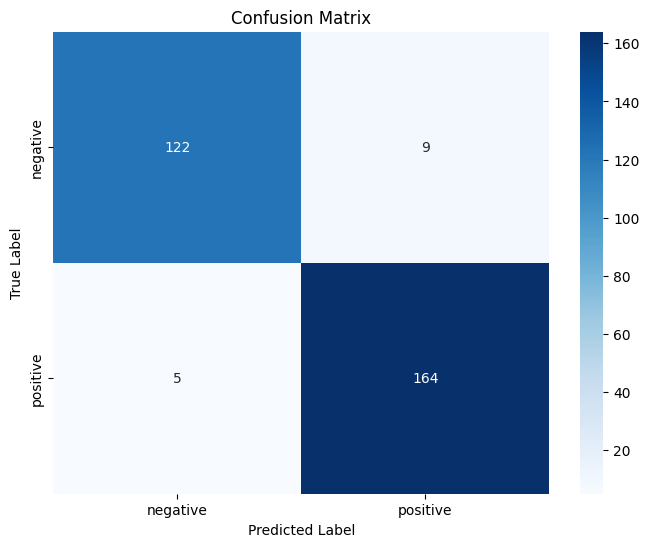

CPU Latency: 13.1674 ms
GPU Latency: 0.9518 ms

--- AIVIVN ---
Test Loss: 0.8301 | Test Acc: 0.7079

✅ Test Accuracy: 0.7079

✅ Test Loss: 0.8301
Phân phối của AIVIVN-2019 TEST SET: {'Long': 876, 'Short': 321, 'Medium': 313}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the aivivn -2019 test set :


              precision    recall  f1-score   support

    negative       0.61      0.85      0.71       130
    positive       0.84      0.58      0.69       170

    accuracy                           0.70       300
   macro avg       0.72      0.72      0.70       300
weighted avg       0.74      0.70      0.70       300



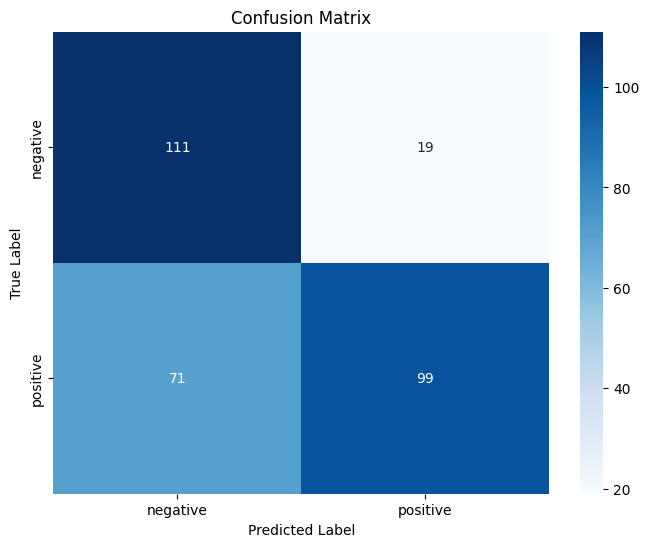


--- CRAWL ---
Test Loss: 0.9595 | Test Acc: 0.5860
Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the crawl test set:


              precision    recall  f1-score   support

    negative       0.46      0.68      0.55       111
    positive       0.74      0.53      0.62       189

    accuracy                           0.59       300
   macro avg       0.60      0.61      0.58       300
weighted avg       0.64      0.59      0.59       300



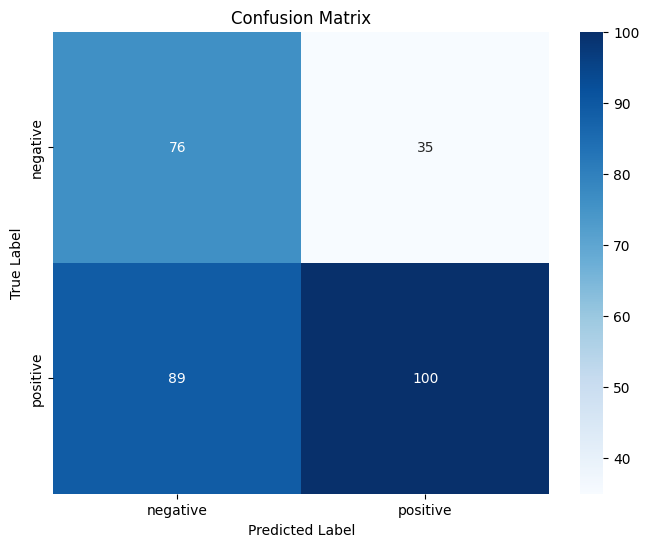

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9533
  Macro F1 Score: 0.9524

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.7000
  Macro F1 Score: 0.6995

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.5867
  Macro F1 Score: 0.5840

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.2533 (25.33%)
  Macro F1 Score Drop: 0.2529 (25.29%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.3667 (36.67%)
  Macro F1 Score Drop: 0.3684 (36.84%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 1, 'Model': 'BiLSTMClassifier', 'Seed': 42, 'UIT-VSFC Accuracy': 0.9533, 'UIT-VSFC Macro-F1': 0.9524, 'UIT-VSFC Std': 0.0067, 'AIVIVN-2

Epoch 01/15 | train_loss=0.4113 train_acc=0.8071 | val_loss=0.2550 val_acc=0.9006
Epoch 02/15 | train_loss=0.2524 train_acc=0.9026 | val_loss=0.2182 val_acc=0.9216
Epoch 03/15 | train_loss=0.2131 train_acc=0.9206 | val_loss=0.2050 val_acc=0.9283
Epoch 04/15 | train_loss=0.1898 train_acc=0.9345 | val_loss=0.1947 val_acc=0.9316
Epoch 05/15 | train_loss=0.1782 train_acc=0.9381 | val_loss=0.1916 val_acc=0.9363
Epoch 06/15 | train_loss=0.1593 train_acc=0.9449 | val_loss=0.1845 val_acc=0.9380
Epoch 07/15 | train_loss=0.1466 train_acc=0.9513 | val_loss=0.1907 val_acc=0.9376
Epoch 08/15 | train_loss=0.1374 train_acc=0.9551 | val_loss=0.1858 val_acc=0.9413
Epoch 09/15 | train_loss=0.1253 train_acc=0.9604 | val_loss=0.1863 val_acc=0.9413
Early stopping tại epoch 9


epoch,▁▂▃▄▅▅▆▇█
train_acc,▁▅▆▇▇▇███
train_loss,█▄▃▃▂▂▂▁▁
val_acc,▁▅▆▆▇▇▇██
val_loss,█▄▃▂▂▁▂▁▁
epoch,9
train_acc,0.96043
train_loss,0.12535
val_acc,0.94131
val_loss,0.18627


Test Loss: 0.1647 | Test Acc: 0.9437

✅ Test Accuracy: 0.9437

✅ Test Loss: 0.1647
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.92      0.94       142
    positive       0.93      0.96      0.95       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



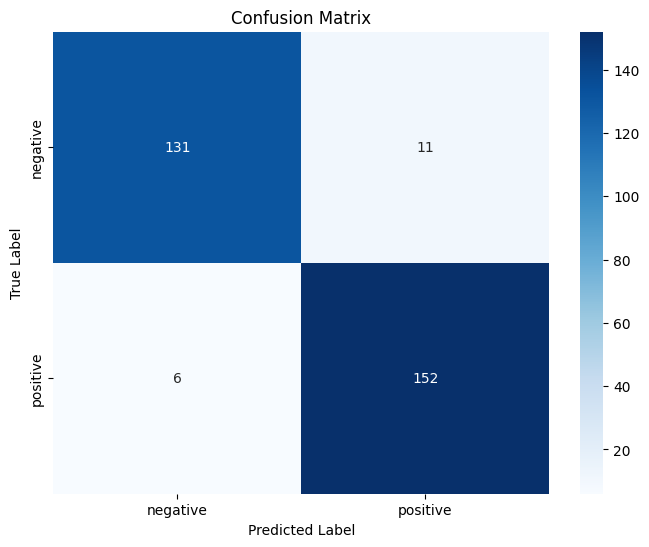

CPU Latency: 3.501 ms
GPU Latency: 0.9231 ms

--- AIVIVN ---
Test Loss: 0.9048 | Test Acc: 0.6682

✅ Test Accuracy: 0.6682

✅ Test Loss: 0.9048
Phân phối của AIVIVN-2019 TEST SET: {'Long': 869, 'Medium': 337, 'Short': 304}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the aivivn -2019 test set :


              precision    recall  f1-score   support

    negative       0.61      0.72      0.66       134
    positive       0.73      0.63      0.68       166

    accuracy                           0.67       300
   macro avg       0.67      0.67      0.67       300
weighted avg       0.68      0.67      0.67       300



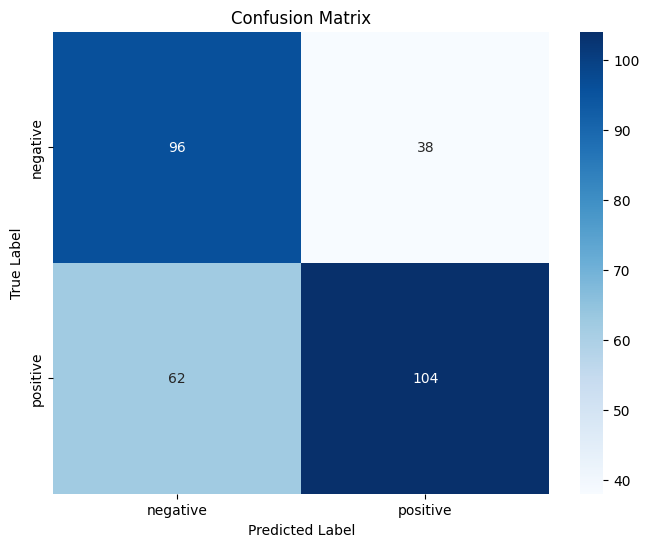


--- CRAWL ---
Test Loss: 0.8303 | Test Acc: 0.6497
Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the crawl test set:


              precision    recall  f1-score   support

    negative       0.52      0.61      0.56       109
    positive       0.75      0.69      0.72       191

    accuracy                           0.66       300
   macro avg       0.64      0.65      0.64       300
weighted avg       0.67      0.66      0.66       300



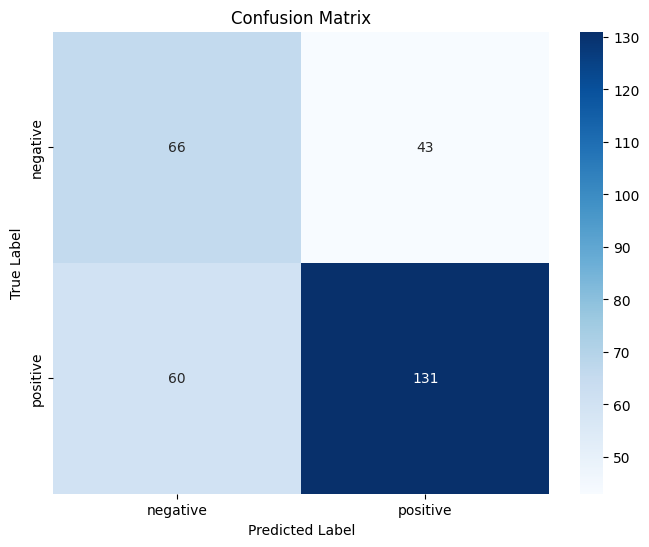

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9433
  Macro F1 Score: 0.9431

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.6667
  Macro F1 Score: 0.6664

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.6567
  Macro F1 Score: 0.6398

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.2767 (27.67%)
  Macro F1 Score Drop: 0.2766 (27.66%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.2867 (28.67%)
  Macro F1 Score Drop: 0.3033 (30.33%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 2, 'Model': 'BiLSTMClassifier', 'Seed': 0, 'UIT-VSFC Accuracy': 0.9433, 'UIT-VSFC Macro-F1': 0.9431, 'UIT-VSFC Std': 0.004, 'AIVIVN-201

Epoch 01/15 | train_loss=0.4405 train_acc=0.7846 | val_loss=0.2716 val_acc=0.8953
Epoch 02/15 | train_loss=0.2497 train_acc=0.9067 | val_loss=0.2369 val_acc=0.9180
Epoch 03/15 | train_loss=0.2072 train_acc=0.9225 | val_loss=0.2204 val_acc=0.9263
Epoch 04/15 | train_loss=0.1986 train_acc=0.9288 | val_loss=0.2122 val_acc=0.9263
Epoch 05/15 | train_loss=0.2033 train_acc=0.9275 | val_loss=0.2121 val_acc=0.9286
Epoch 06/15 | train_loss=0.1549 train_acc=0.9477 | val_loss=0.2014 val_acc=0.9316
Epoch 07/15 | train_loss=0.1440 train_acc=0.9524 | val_loss=0.1897 val_acc=0.9360
Epoch 08/15 | train_loss=0.1381 train_acc=0.9534 | val_loss=0.1838 val_acc=0.9393
Epoch 09/15 | train_loss=0.1266 train_acc=0.9598 | val_loss=0.1994 val_acc=0.9370
Epoch 10/15 | train_loss=0.1498 train_acc=0.9530 | val_loss=0.2188 val_acc=0.9266
Epoch 11/15 | train_loss=0.1414 train_acc=0.9533 | val_loss=0.1888 val_acc=0.9423
Early stopping tại epoch 11


epoch,▁▂▂▃▄▅▅▆▇▇█
train_acc,▁▆▇▇▇██████
train_loss,█▄▃▃▃▂▁▁▁▂▁
val_acc,▁▄▆▆▆▆▇█▇▆█
val_loss,█▅▄▃▃▂▁▁▂▄▁
epoch,11
train_acc,0.95332
train_loss,0.14135
val_acc,0.94231
val_loss,0.18876


Test Loss: 0.1572 | Test Acc: 0.9510

✅ Test Accuracy: 0.9510

✅ Test Loss: 0.1572
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.96      0.95       139
    positive       0.97      0.95      0.96       161

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



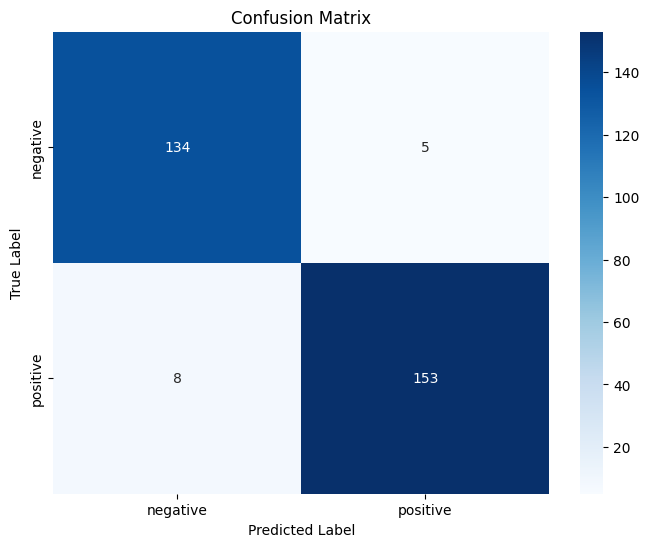

CPU Latency: 3.8868 ms
GPU Latency: 0.9467 ms

--- AIVIVN ---
Test Loss: 0.8914 | Test Acc: 0.6887

✅ Test Accuracy: 0.6887

✅ Test Loss: 0.8914
Phân phối của AIVIVN-2019 TEST SET: {'Long': 864, 'Medium': 328, 'Short': 318}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the aivivn -2019 test set :


              precision    recall  f1-score   support

    negative       0.55      0.84      0.66       110
    positive       0.86      0.61      0.71       190

    accuracy                           0.69       300
   macro avg       0.71      0.72      0.69       300
weighted avg       0.75      0.69      0.69       300



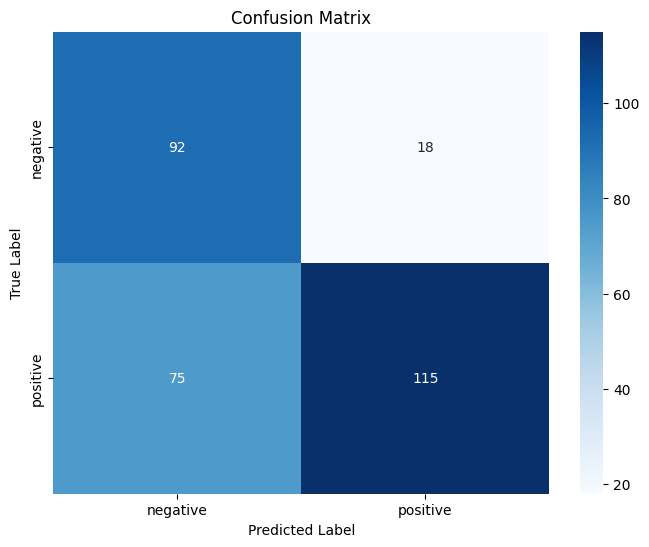


--- CRAWL ---
Test Loss: 0.8491 | Test Acc: 0.6561
Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the crawl test set:


              precision    recall  f1-score   support

    negative       0.53      0.68      0.59       109
    positive       0.78      0.65      0.71       191

    accuracy                           0.66       300
   macro avg       0.65      0.67      0.65       300
weighted avg       0.69      0.66      0.67       300



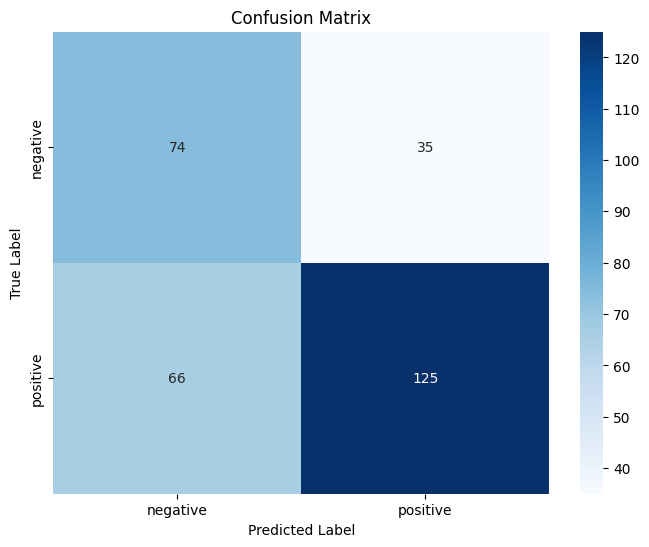

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9567
  Macro F1 Score: 0.9565

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.6900
  Macro F1 Score: 0.6882

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.6633
  Macro F1 Score: 0.6533

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.2667 (26.67%)
  Macro F1 Score Drop: 0.2683 (26.83%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.2933 (29.33%)
  Macro F1 Score Drop: 0.3032 (30.32%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 3, 'Model': 'BiLSTMClassifier', 'Seed': 1, 'UIT-VSFC Accuracy': 0.9567, 'UIT-VSFC Macro-F1': 0.9565, 'UIT-VSFC Std': 0.0028, 'AIVIVN-20

Epoch 01/15 | train_loss=0.4081 train_acc=0.8061 | val_loss=0.2538 val_acc=0.9020
Epoch 02/15 | train_loss=0.2478 train_acc=0.9084 | val_loss=0.2348 val_acc=0.9186
Epoch 03/15 | train_loss=0.2125 train_acc=0.9221 | val_loss=0.2107 val_acc=0.9320
Epoch 04/15 | train_loss=0.1873 train_acc=0.9320 | val_loss=0.2013 val_acc=0.9323
Epoch 05/15 | train_loss=0.1640 train_acc=0.9410 | val_loss=0.1921 val_acc=0.9350
Epoch 06/15 | train_loss=0.1577 train_acc=0.9468 | val_loss=0.1913 val_acc=0.9376
Epoch 07/15 | train_loss=0.1563 train_acc=0.9478 | val_loss=0.1918 val_acc=0.9370
Epoch 08/15 | train_loss=0.1329 train_acc=0.9555 | val_loss=0.1914 val_acc=0.9400
Epoch 09/15 | train_loss=0.1260 train_acc=0.9588 | val_loss=0.1783 val_acc=0.9456
Epoch 10/15 | train_loss=0.1413 train_acc=0.9542 | val_loss=0.1755 val_acc=0.9423
Epoch 11/15 | train_loss=0.1123 train_acc=0.9619 | val_loss=0.1802 val_acc=0.9423
Epoch 12/15 | train_loss=0.1057 train_acc=0.9658 | val_loss=0.1772 val_acc=0.9450
Epoch 13/15 | tr

epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
train_acc,▁▅▆▆▇▇▇▇█▇███
train_loss,█▄▄▃▃▂▂▂▂▂▁▁▁
val_acc,▁▄▆▆▆▇▇▇█▇▇██
val_loss,█▆▄▃▂▂▂▂▁▁▁▁▂
epoch,13
train_acc,0.96982
train_loss,0.09725
val_acc,0.94398
val_loss,0.18357


Test Loss: 0.1606 | Test Acc: 0.9497

✅ Test Accuracy: 0.9497

✅ Test Loss: 0.1606
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.94      0.94       144
    positive       0.95      0.95      0.95       156

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



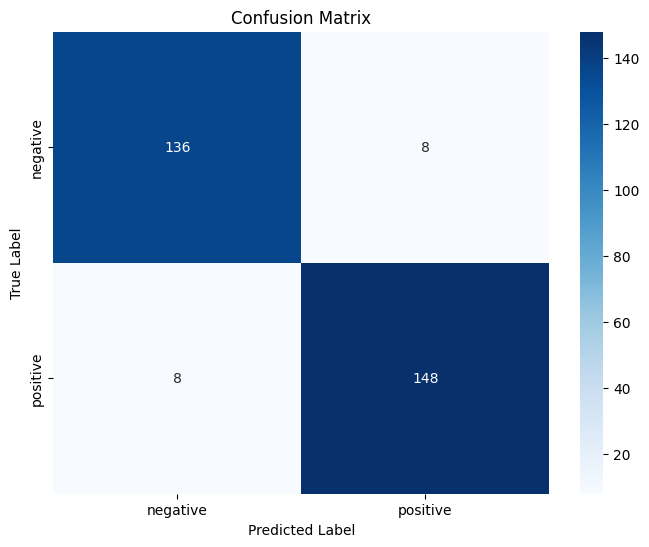

CPU Latency: 5.8533 ms
GPU Latency: 1.6827 ms

--- AIVIVN ---
Test Loss: 0.8029 | Test Acc: 0.7079

✅ Test Accuracy: 0.7079

✅ Test Loss: 0.8029
Phân phối của AIVIVN-2019 TEST SET: {'Long': 870, 'Medium': 336, 'Short': 304}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the aivivn -2019 test set :


              precision    recall  f1-score   support

    negative       0.62      0.89      0.73       124
    positive       0.89      0.61      0.72       176

    accuracy                           0.73       300
   macro avg       0.75      0.75      0.73       300
weighted avg       0.77      0.73      0.73       300



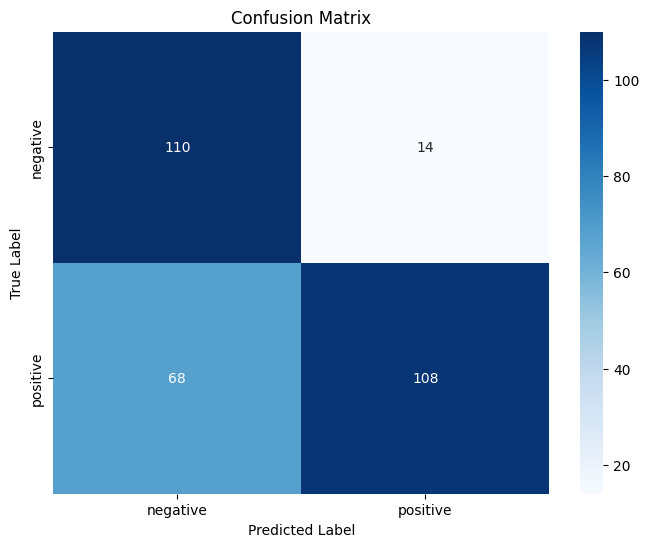


--- CRAWL ---
Test Loss: 0.8915 | Test Acc: 0.6242
Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the crawl test set:


              precision    recall  f1-score   support

    negative       0.48      0.74      0.58       108
    positive       0.79      0.55      0.65       192

    accuracy                           0.62       300
   macro avg       0.63      0.64      0.61       300
weighted avg       0.68      0.62      0.62       300



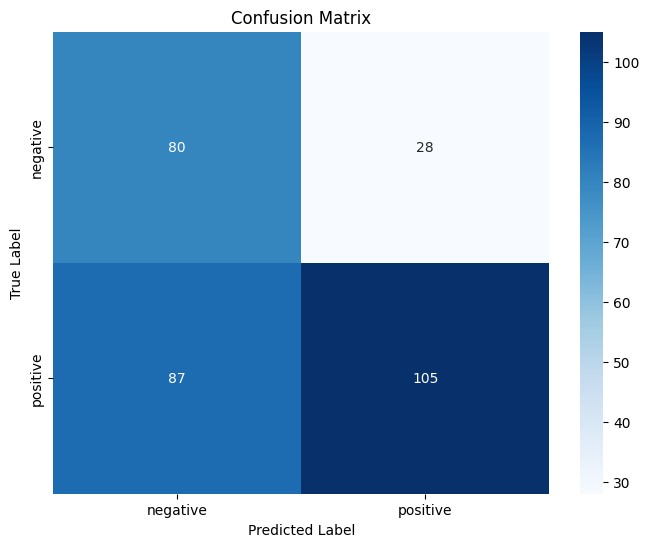

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9467
  Macro F1 Score: 0.9466

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.7267
  Macro F1 Score: 0.7267

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.6167
  Macro F1 Score: 0.6140

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.2200 (22.00%)
  Macro F1 Score Drop: 0.2199 (21.99%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.3300 (33.00%)
  Macro F1 Score Drop: 0.3326 (33.26%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 4, 'Model': 'BiLSTMClassifier', 'Seed': 123, 'UIT-VSFC Accuracy': 0.9467, 'UIT-VSFC Macro-F1': 0.9466, 'UIT-VSFC Std': 0.0021, 'AIVIVN-

Epoch 01/15 | train_loss=0.4369 train_acc=0.7959 | val_loss=0.2607 val_acc=0.8960
Epoch 02/15 | train_loss=0.2523 train_acc=0.9036 | val_loss=0.2152 val_acc=0.9220
Epoch 03/15 | train_loss=0.2033 train_acc=0.9284 | val_loss=0.2165 val_acc=0.9280
Epoch 04/15 | train_loss=0.1907 train_acc=0.9340 | val_loss=0.2002 val_acc=0.9296
Epoch 05/15 | train_loss=0.1712 train_acc=0.9421 | val_loss=0.1977 val_acc=0.9363
Epoch 06/15 | train_loss=0.1571 train_acc=0.9460 | val_loss=0.1948 val_acc=0.9386
Epoch 07/15 | train_loss=0.1425 train_acc=0.9532 | val_loss=0.1820 val_acc=0.9386
Epoch 08/15 | train_loss=0.1305 train_acc=0.9578 | val_loss=0.1981 val_acc=0.9386
Epoch 09/15 | train_loss=0.1224 train_acc=0.9628 | val_loss=0.1852 val_acc=0.9410
Epoch 10/15 | train_loss=0.1264 train_acc=0.9602 | val_loss=0.1771 val_acc=0.9436
Epoch 11/15 | train_loss=0.1101 train_acc=0.9653 | val_loss=0.1801 val_acc=0.9420
Epoch 12/15 | train_loss=0.1055 train_acc=0.9668 | val_loss=0.1782 val_acc=0.9416
Epoch 13/15 | tr

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▅▆▆▇▇▇▇█▇█████
train_loss,█▄▃▃▃▂▂▂▂▂▁▁▁▁▁
val_acc,▁▅▆▆▇▇▇▇███████
val_loss,█▄▄▃▃▃▂▃▂▁▁▁▁▃▁
epoch,15
train_acc,0.9731
train_loss,0.08981
val_acc,0.94331
val_loss,0.17932


Test Loss: 0.1464 | Test Acc: 0.9517

✅ Test Accuracy: 0.9517

✅ Test Loss: 0.1464
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.96      0.96       137
    positive       0.96      0.96      0.96       163

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



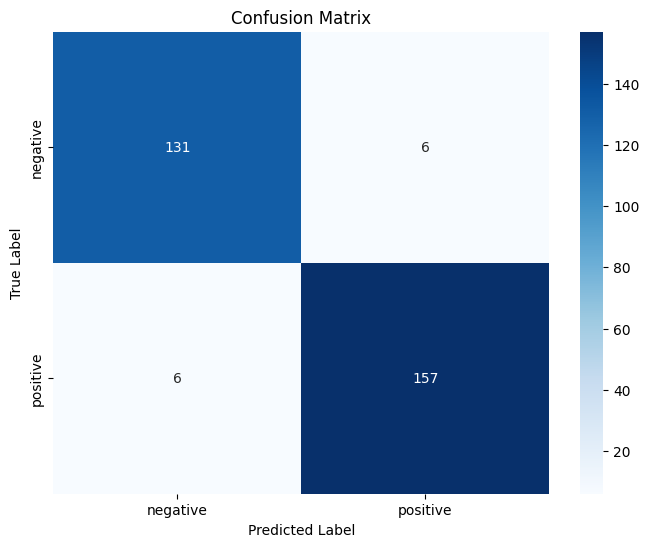

CPU Latency: 4.3257 ms
GPU Latency: 0.9366 ms

--- AIVIVN ---
Test Loss: 0.7894 | Test Acc: 0.7464

✅ Test Accuracy: 0.7464

✅ Test Loss: 0.7894
Phân phối của AIVIVN-2019 TEST SET: {'Long': 879, 'Medium': 327, 'Short': 304}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the aivivn -2019 test set :


              precision    recall  f1-score   support

    negative       0.63      0.84      0.72       122
    positive       0.86      0.67      0.75       178

    accuracy                           0.74       300
   macro avg       0.74      0.75      0.74       300
weighted avg       0.77      0.74      0.74       300



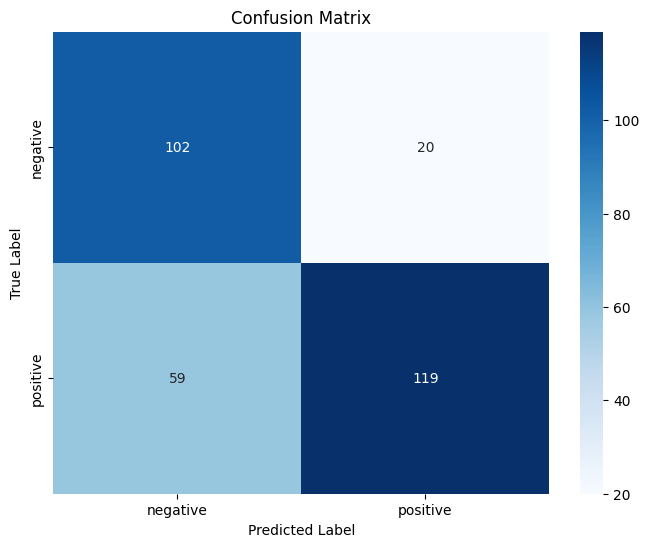


--- CRAWL ---
Test Loss: 0.9914 | Test Acc: 0.6369
Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}
Trả về classifiction report và confusion matrix 300 mẫu.
Classification Report on the crawl test set:


              precision    recall  f1-score   support

    negative       0.50      0.77      0.61       108
    positive       0.81      0.57      0.67       192

    accuracy                           0.64       300
   macro avg       0.66      0.67      0.64       300
weighted avg       0.70      0.64      0.65       300



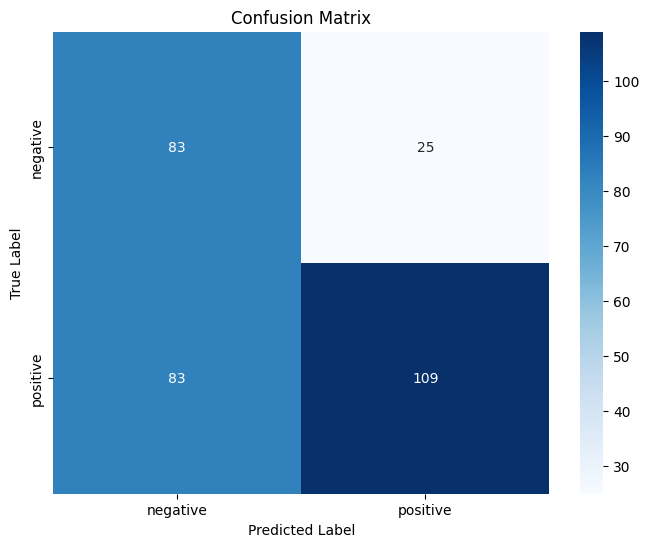

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9600
  Macro F1 Score: 0.9597

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.7367
  Macro F1 Score: 0.7358

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.6400
  Macro F1 Score: 0.6373

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.2233 (22.33%)
  Macro F1 Score Drop: 0.2239 (22.39%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.3200 (32.00%)
  Macro F1 Score Drop: 0.3224 (32.24%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 5, 'Model': 'BiLSTMClassifier', 'Seed': 2026, 'UIT-VSFC Accuracy': 0.96, 'UIT-VSFC Macro-F1': 0.9597, 'UIT-VSFC Std': 0.0035, 'AIVIVN-2

In [ ]:

seeds = [42, 0, 1, 123, 2026]

results = []

# Add this line to prevent interactive wandb login prompts
wandb.login(relogin=True)

for seed in seeds:
    print(f'\n{"="*60}')
    print(f'  Training with seed = {seed}')
    print(f'={"="*59}')

    # ── 1. Set seed TRƯỚC MỌI THỨ ──────────────────────────────
    set_seed(seed)

    #Hiện tại không dùng pretrain embedding
    # ── 2. Build embedding matrix SAU set_seed (random OOV reproducible) ──
    #embedding_matrix = build_embedding_matrix(tokenizer, w2v_model, MAX_WORDS, EMBEDDING_DIM)

    # ── 3. Build model SAU set_seed (weight init reproducible) ─
    model = build_bilstm_model(
        max_words=MAX_WORDS,
        max_len=MAX_LEN,
        num_classes=NUM_CLASSES,
        embedding_matrix=None,
        embedding_dim=EMBEDDING_DIM,
        trainable_embedding=True,
    )

    # ── 4. Train (train_model sẽ gọi set_seed lại bên trong) ───
    history = train_model(
        model, X_train, y_train, X_valid, y_valid,
        epochs=15, batch_size=32, patience=3, seed=seed,
        project_name='vietnamese-sentiment-analysis-bilstm-model-log',
        run_name=f'bilstm_run_seed_{seed}'
    )

    print('='*50)
    test_loss, test_acc = evaluate_test(model, X_test, y_test)
    print(f'\n✅ Test Accuracy: {test_acc:.4f}')
    print(f'\n✅ Test Loss: {test_loss:.4f}')

    # Lấy nhãn dự đoán cho bộ test uit-vsfc
    y_pred = predict_test(model, X_test)
    test_df['pred_label'] = y_pred

    # Chia bucket length
    test_df = add_length_category(test_df, LOW_THRESHOLD, HIGH_THRESHOLD,
                                  df_name='UIT-VSFC TEST SET')

    # Get new sample
    test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    print('='*50)
    print('Trả về classifiction report và confusion matrix 300 mẫu.')
    # vẽ classification report
    plot_classification_report_test(test_sample_df['label'].astype(int).values, test_sample_df['pred_label'].astype(int).values)

    print('='*50)
    #Vẽ Confusion Matrix
    plot_confusion_matrix_test(test_sample_df['label'].astype(int).values, test_sample_df['pred_label'].astype(int).values)




    # ── Latency ──────────────────────────────────────────
    sample_texts = list(test_df['text'][:10])

    cpu_latency = measure_cpu_latency(model, sample_texts, tokenizer)
    gpu_latency = measure_gpu_latency(model, sample_texts, tokenizer)
    print("="*50)
    print(f"CPU Latency: {cpu_latency} ms")
    print("="*50)
    print(f"GPU Latency: {gpu_latency} ms")

    # ── AIVIVN ───────────────────────────────────────────
    print("\n--- AIVIVN ---")

    aivivn_sample_df = sample_dataframe_aivivn(
        test_df_aivivn, n=len(test_df), seed=seed)

    X_aivivn_sample, y_test_aivivn = tokenizer_test_aivivn(
        aivivn_sample_df, max_len=MAX_LEN)

    print('='*50)
    aivivn_test_loss, aivivn_test_acc = evaluate_aivivn(
        model, X_aivivn_sample, y_test_aivivn)
    print(f'\n✅ Test Accuracy: {aivivn_test_acc:.4f}')
    print(f'\n✅ Test Loss: {aivivn_test_loss:.4f}')

    # Lấy nhãn dự đoán cho bộ aivivn-2019
    y_pred_aivivn = predict_aivivn(model, X_aivivn_sample, y_test_aivivn)
    aivivn_sample_df['pred_label'] = y_pred_aivivn

    # Chia bucket length
    aivivn_sample_df = add_length_category(aivivn_sample_df, LOW_THRESHOLD, HIGH_THRESHOLD,
                                  df_name='AIVIVN-2019 TEST SET')

    # Get new sample
    aivivn_new_sample_df=aivivn_sample_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    print('='*50)
    print('Trả về classifiction report và confusion matrix 300 mẫu.')
    # vẽ classification report
    plot_classification_report_aivivn(aivivn_new_sample_df['label'].astype(int).values, aivivn_new_sample_df['pred_label'].astype(int).values)

    print('='*50)
    #Vẽ Confusion Matrix
    plot_confusion_matrix_aivivn(aivivn_new_sample_df['label'].astype(int).values, aivivn_new_sample_df['pred_label'].astype(int).values)

    print('='*50)
    # Preview prediction
    preview_predictions_aivivn(aivivn_new_sample_df)


    # ── CRAWL ────────────────────────────────────────────
    print("\n--- CRAWL ---")
    crawl_sample_df = crawl_df.copy()

    X_crawl_sample, y_test_crawl = tokenizer_test_crawl(
        crawl_sample_df, max_len=MAX_LEN)

    crawl_test_loss, crawl_test_acc = evaluate_crawl(
        model, X_crawl_sample, y_test_crawl)

    y_pred_crawl = predict_crawl(model, X_crawl_sample, y_test_crawl)
    crawl_sample_df['pred_label'] = y_pred_crawl

    # Chia bucket length
    crawl_sample_df = add_length_category(crawl_sample_df, LOW_THRESHOLD, HIGH_THRESHOLD,
                                  df_name='CRAWL DATA SET')
    # Get new sample
    crawl_new_sample_df = crawl_sample_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    print('='*50)
    print('Trả về classifiction report và confusion matrix 300 mẫu.')
    # vẽ classification report
    plot_classification_report_craw(crawl_new_sample_df['label'].astype(int).values, crawl_new_sample_df['pred_label'].astype(int).values)
    print('='*50)
    #Vẽ Confusion Matrix
    plot_confusion_matrix_crawl(crawl_new_sample_df['label'].astype(int).values, crawl_new_sample_df['pred_label'].astype(int).values)

    print('='*50)
    # Preview prediction
    preview_predictions_crawl(crawl_new_sample_df)


    print('='*50)
    # Print domain shift
    domain_shift_analysis(
        test_sample_df=test_sample_df,
        aivivn_sample_df=aivivn_new_sample_df,
        crawl_sample_df=crawl_new_sample_df
    )

    # Log result
    log_result(
        model_name=model.__class__.__name__,
        seed=seed,
        test_sample_df = test_sample_df,
        aivivn_sample_df = aivivn_new_sample_df,
        crawl_sample_df = crawl_new_sample_df,
        cpu_latency=cpu_latency,
        gpu_latency=gpu_latency
    )

    # Log domain shift
    log_result_domain_shift(
        model_name=model.__class__.__name__,
        seed=seed,
        test_sample_df = test_sample_df,
        aivivn_sample_df=aivivn_new_sample_df,
        crawl_sample_df=crawl_new_sample_df
    )

    print("="*50)
    # Dự đoán một câu
    predict_sentence('Giảng viên truyền cảm hứng.')

    # Lưu kết quả từng seed vào list
    uit_vsfc_macro_f1 = round(float(f1_score(
        test_sample_df['label'].astype(int).values,
        test_sample_df['pred_label'].astype(int).values,
        average='macro'
    )), 4)

    results.append({
        'seed': seed,
        'macro_f1': uit_vsfc_macro_f1,
        'model_state': model.state_dict(),
        #'embedding': embedding_matrix.copy()
    })

    print(f'\n✅ Kết thúc train seed {seed}')


# Sau vòng lặp for seed in seeds:
best = max(results, key=lambda x: x['macro_f1'])
print(f'✅ Best seed: {best["seed"]} | Macro-F1: {best["macro_f1"]}')


In [ ]:
# Xem CSV

print("\n--- Training Log ---")
df_log_training = pd.read_csv(LOG_TRAINING_FILE)
display(df_log_training)
print("\n✅ Displayed training log.")

print("\n==============================")

print("\n--- Domain Shift Log ---")
df_log_domain_shift = pd.read_csv(LOG_DOMAIN_SHIFT_FILE)
display(df_log_domain_shift)
print("\n✅ Displayed domain shift log.")






--- Training Log ---


,ID,Model,Seed,UIT-VSFC Accuracy,UIT-VSFC Macro-F1,UIT-VSFC Std,AIVIVN-2019 Accuracy,AIVIVN-2019 Macro-F1,AIVIVN-2019 Std,CRAWL Accuracy,...,GPU Latency,Short (UIT-VSFC Test) F1,Medium (UIT-VSFC Test) F1,Long (UIT-VSFC Test) F1,Short (AIVIVN-2019 Test) F1,Medium (AIVIVN-2019 Test) F1,Long (AIVIVN-2019 Test) F1,Short (CRAWL Test) F1,Medium (CRAWL Test) F1,Long (CRAWL Test) F1
0,1,BiLSTMClassifier,42,0.9533,0.9524,0.0067,0.7000,0.6995,0.0120,0.5867,...,0.9518 ms,0.9747,0.9535,0.8917,0.6971,0.6653,0.7048,0.5678,0.6048,0.5663
1,2,BiLSTMClassifier,0,0.9433,0.9431,0.0040,0.6667,0.6664,0.0089,0.6567,...,0.9231 ms,0.9664,0.9210,0.9117,0.6761,0.6298,0.6622,0.5076,0.7087,0.6106
2,3,BiLSTMClassifier,1,0.9567,0.9565,0.0028,0.6900,0.6882,0.0239,0.6633,...,0.9467 ms,0.9810,0.9390,0.9127,0.6637,0.7111,0.6527,0.6237,0.7177,0.6175
3,4,BiLSTMClassifier,123,0.9467,0.9466,0.0021,0.7267,0.7267,0.0018,0.6167,...,1.6827 ms,0.9447,0.9326,0.9515,0.7285,0.7417,0.7178,0.5312,0.7636,0.5446
4,5,BiLSTMClassifier,2026,0.9600,0.9597,0.0035,0.7367,0.7358,0.0150,0.6400,...,0.9366 ms,0.9845,0.9364,0.9307,0.7489,0.6486,0.7566,0.5764,0.7070,0.6081



✅ Displayed training log.


--- Domain Shift Log ---


,ID,Model,Seed,In-domain Accuracy,Out-of-domain Accuracy,Wild-test Accuracy,In-domain F1,Out-of-domain F1,Wild-test F1,Accuracy Drop(In-domain F1 - Out-of-domain F1) (%),Accuracy Drop(In-domain F1 - Wild-test F1) (%),F1 Score Drop(In-domain F1 - Out-of-domain F1) (%),F1 Score Drop(In-domain F1 - Wild-test F1) (%),Lỗi chính
0,1,BiLSTMClassifier,42,0.9533,0.7000,0.5867,0.9524,0.6995,0.5840,25.33 %,36.66 %,25.29 %,36.84 %,NaN
1,2,BiLSTMClassifier,0,0.9433,0.6667,0.6567,0.9431,0.6664,0.6398,27.66 %,28.66 %,27.67 %,30.33 %,NaN
2,3,BiLSTMClassifier,1,0.9567,0.6900,0.6633,0.9565,0.6882,0.6533,26.67 %,29.34 %,26.83 %,30.32 %,NaN
3,4,BiLSTMClassifier,123,0.9467,0.7267,0.6167,0.9466,0.7267,0.6140,22.00 %,33.00 %,21.99 %,33.26 %,NaN
4,5,BiLSTMClassifier,2026,0.9600,0.7367,0.6400,0.9597,0.7358,0.6373,22.33 %,32.00 %,22.39 %,32.24 %,NaN



✅ Displayed domain shift log.


In [ ]:
from google.colab import files

# tải file csv về
#files.download(LOG_TRAINING_FILE)
#files.download(LOG_DOMAIN_SHIFT_FILE)

#Tải model về
#files.download('/content/models/bilstm/model.pt')
#files.download('/content/models/bilstm/embedding.pt')
#files.download('/content/models/bilstm/tokenizer.pkl')
#files.download('/content/models/bilstm/config.json')

#13. Lưu model cho demo

In [ ]:
import json
import os

SAVE_DIR = '/content/models/bilstm'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Lưu trọng số model (đầy đủ, kể cả embedding đã train)
torch.save(best['model_state'], f'{SAVE_DIR}/model.pt')

# 2. Lưu vocab dạng JSON thuần — KHÔNG pickle nguyên object SimpleTokenizer,
#    để app.py không cần định nghĩa lại class SimpleTokenizer mới đọc được.
vocab_export = {
    "word_index": tokenizer.word_index,   # {"<OOV>":1, "từ":2, ...}
    "num_words": tokenizer.num_words,
    "oov_token": tokenizer.oov_token,
}
with open(f'{SAVE_DIR}/vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_export, f, ensure_ascii=False, indent=2)

# 3. Config đầy đủ tham số kiến trúc + preprocessing + label mapping
config = {
    "best_seed": best['seed'],
    "best_macro_f1": best['macro_f1'],
    "max_words": MAX_WORDS,
    "max_len": MAX_LEN,
    "num_classes": NUM_CLASSES,          # = 2 (binary)
    "embedding_dim": EMBEDDING_DIM,
    "lstm_units": 64,
    "dropout1": 0.6,
    "dropout2": 0.5,
    "trainable_embedding": False,
    "label_map_inv": {"0": "negative", "1": "positive"},
    "segmenter": "VnCoreNLP",            # nhắc app.py phải dùng VnCoreNLP, không phải underthesea
    "preprocessing_order": ["normalize_text", "segment_text", "tokenizer.texts_to_sequences", "pad_sequences"]
}
with open(f'{SAVE_DIR}/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f'✅ Đã lưu model.pt, vocab.json, config.json vào {SAVE_DIR}')

✅ Đã lưu model.pt, vocab.json, config.json vào /content/models/bilstm


In [ ]:
#from google.colab import files
#files.download(f'{SAVE_DIR}/model.pt')
#files.download(f'{SAVE_DIR}/vocab.json')
#files.download(f'{SAVE_DIR}/config.json')